# Preparación de datos para modelado predictivo de demanda

Este notebook desarrolla la preparación del dataset consolidado para la evaluación de algoritmos de forecast aplicados a artículos previamente filtrados como aptos para predicción.

La base de entrada corresponde al dataframe consolidado posterior a la etapa de clusterización, donde cada artículo conserva su historial de ventas y adicionalmente cuenta con una asignación de cluster, una descripción interpretativa del tipo de demanda y una lista preliminar de modelos candidatos de forecast.

## Contexto metodológico

En los notebooks anteriores se realizó primero una fotografía matemática del comportamiento histórico de ventas de los artículos aplicables a forecast. Posteriormente, se ejecutó un proceso de clusterización utilizando variables asociadas a volumen, frecuencia, recencia, variabilidad, concentración de picos, tendencia y posible estacionalidad.

El resultado de la clusterización permitió segmentar los artículos en grupos matemáticamente diferenciados. Estos clusters no representan todavía modelos predictivos, sino perfiles de comportamiento de demanda que servirán como punto de partida para seleccionar y comparar familias de algoritmos de forecast.

## Objetivo del notebook

El objetivo principal de este notebook es transformar el dataset consolidado en una estructura adecuada para entrenamiento y evaluación de modelos predictivos. Para ello, se preparará una base supervisada donde cada observación represente el comportamiento histórico de un artículo en un período determinado y se construyan variables explicativas a partir de información pasada.

La finalidad es evitar data leakage y garantizar que los modelos utilicen únicamente información disponible antes del período que se desea predecir.

## Procedimiento general

1. Importar el dataframe consolidado con historial de ventas, cluster y modelos candidatos.
2. Validar la estructura del dataset y las columnas necesarias.
3. Identificar las columnas mensuales de venta histórica.
4. Convertir el dataset de formato ancho a formato largo, generando una estructura artículo-mes.
5. Ordenar cronológicamente las ventas por artículo.
6. Construir variables temporales tipo lag.
7. Construir variables móviles, como medias, desviaciones y ventas acumuladas.
8. Definir la variable objetivo de predicción.
9. Integrar variables de clusterización y atributos maestros del artículo.
10. Preparar divisiones temporales de entrenamiento y prueba.
11. Definir métricas de evaluación para comparar algoritmos.
12. Preparar la base final para el entrenamiento de modelos por cluster.

## Enfoque de predicción

El primer enfoque de modelado será supervisado. En lugar de predecir directamente desde una única fila por artículo, se construirá una tabla histórica en formato artículo-mes. Esta estructura permitirá generar variables basadas en períodos anteriores, como ventas rezagadas, promedios móviles y señales recientes de demanda.

La variable objetivo inicial será la demanda del siguiente período mensual. Posteriormente podrá evaluarse un segundo objetivo basado en demanda acumulada en una ventana futura, por ejemplo tres meses, con el fin de acercar el modelo a decisiones de reabastecimiento.

## Relación con la clusterización

La columna `cluster_kmeans_final` será utilizada como una variable metodológica clave. Esta permitirá evaluar si diferentes grupos de artículos presentan mejores resultados con distintas familias de modelos.

Los modelos candidatos asignados en el capítulo anterior no representan todavía el modelo ganador. Su función es orientar la matriz inicial de experimentación. La selección definitiva se realizará empíricamente mediante métricas de error y validación temporal.

## Consideraciones importantes

Durante esta etapa será fundamental evitar el uso de información futura para construir variables predictoras. Todas las variables utilizadas para predecir un mes determinado deberán calcularse únicamente con información disponible en meses anteriores.

Además, debido a la naturaleza de los repuestos industriales, se prestará especial atención a artículos con demanda intermitente, valores en cero, picos de venta y diferencias significativas entre clusters.

In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================
# En esta sección se importan las librerías necesarias para:
# - manipulación de datos
# - preparación temporal del dataset
# - construcción de variables supervisadas
# - validación de estructura
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# ============================================================
# 2. Carga del dataframe consolidado
# ============================================================
# Este archivo corresponde al dataset histórico enriquecido con:
# - cluster_kmeans_final
# - descripcion_cluster
# - modelos_candidatos_forecast
# - tipo_demanda
# - modelo_forecast preliminar
# ============================================================

ruta_archivo = "./Datos/dataframe_aplica_forecast_true_clusterizado_modelos_2026_07_18.xlsx"

df_modelado = pd.read_excel(
    ruta_archivo
)

print("Dimensiones del dataframe consolidado:")
print(df_modelado.shape)

df_modelado.head()

Dimensiones del dataframe consolidado:
(450, 128)


,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,ultima_fecha_compra,ultimo_precio_compra,...,monto_riesgo_inmediato,monto_riesgo_proximo,score_prioridad_articulo,venta_mensual_en_revision,venta_promedio_reciente_last_6m,ratio_venta_reciente_6m,motivo_aplica_forecast,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,UNI,SIEMENS,2026-06-26,32.680000,...,0.000000,46283.713583,46283.713583,20634.356250,395.500000,0.845612,Aplica forecast,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,CM2,HABASIT ROCUA,2026-01-31,0.007366,...,0.000000,0.000000,0.000000,0.000000,240040.970000,0.964050,Aplica forecast,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-02-27,19.335359,...,0.000000,3384.525384,3384.525384,0.000000,43.551667,0.507788,Aplica forecast,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,UNI,PRECISION INC,2026-05-31,51.088667,...,0.000000,0.000000,0.000000,0.000000,32.166667,1.349650,Aplica forecast,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2026-06-01,21.100484,...,7043.938685,0.000000,7043.938685,1654.161893,71.051667,1.223552,Aplica forecast,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random..."


In [3]:
# ============================================================
# 3. Validación inicial del dataframe consolidado
# ============================================================
# Objetivo:
# Confirmar que el dataframe contiene las columnas necesarias
# para iniciar la preparación del dataset supervisado de forecast.
# ============================================================

print("Dimensiones del dataframe:")
print(df_modelado.shape)

print("\nColumnas disponibles:")
print(df_modelado.columns.tolist())

print("\nTipos de datos:")
df_modelado.info()

Dimensiones del dataframe:
(450, 128)

Columnas disponibles:
['codigo_articulo', 'descripcion_completa', 'grupo_articulo', 'categoria', 'subcategoria', 'tipo', 'unidad_medida_inventario', 'marca_fabricante', 'ultima_fecha_compra', 'ultimo_precio_compra', 'costo_promedio', 'codigo_bodega', 'stock_en_mano', 'stock_comprometido', 'stock_en_pedido_transito', 'total_unidades_vendidas_24m', 'venta_anual_promedio_24m', 'conteo_facturas_24m', 'cantidad_clientes_24m', 'frecuencia_venta_mensual_24m', 'conteo_compras_proveedores_24m', 'cantidad_proveedores_24m', 'frecuencia_compra_mensual_24m', 'meses_promedio_entre_compras_24m', 'cantidad_entradas_compra_con_oc', 'lead_time_promedio_dias', 'lead_time_min_dias', 'lead_time_max_dias', 'ultima_entrada_mercancia', 'cantidad_promedio_pedido_24m', 'cliente_1', 'cliente_2', 'cliente_3', 'cliente_4', 'cliente_5', 'cantidad_minima_compra', 'stock_minimo', 'stock_maximo', 'precio_lista_11_promociones_ecommerce', 'precio_lista_12_b2b_vip', 'precio_lista_13

In [4]:
# ============================================================
# 4. Identificación de columnas mensuales de venta
# ============================================================
# Objetivo:
# Detectar únicamente las columnas mensuales de venta.
# Se excluyen columnas agregadas como venta_total_2024,
# venta_total_2025 y venta_total_2026.
# ============================================================

meses_es = [
    "enero", "febrero", "marzo", "abril", "mayo", "junio",
    "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"
]

columnas_venta_mensual = [
    col for col in df_modelado.columns
    if col.startswith("venta_")
    and any(mes in col for mes in meses_es)
]

print("Cantidad de columnas mensuales detectadas:")
print(len(columnas_venta_mensual))

print("\nColumnas mensuales detectadas:")
columnas_venta_mensual

Cantidad de columnas mensuales detectadas:
31

Columnas mensuales detectadas:


['venta_enero_2024',
 'venta_febrero_2024',
 'venta_marzo_2024',
 'venta_abril_2024',
 'venta_mayo_2024',
 'venta_junio_2024',
 'venta_julio_2024',
 'venta_agosto_2024',
 'venta_septiembre_2024',
 'venta_octubre_2024',
 'venta_noviembre_2024',
 'venta_diciembre_2024',
 'venta_enero_2025',
 'venta_febrero_2025',
 'venta_marzo_2025',
 'venta_abril_2025',
 'venta_mayo_2025',
 'venta_junio_2025',
 'venta_julio_2025',
 'venta_agosto_2025',
 'venta_septiembre_2025',
 'venta_octubre_2025',
 'venta_noviembre_2025',
 'venta_diciembre_2025',
 'venta_enero_2026',
 'venta_febrero_2026',
 'venta_marzo_2026',
 'venta_abril_2026',
 'venta_mayo_2026',
 'venta_junio_2026',
 'venta_julio_2026']

In [5]:
# ============================================================
# 5. Validar exclusión de columnas agregadas
# ============================================================

columnas_totales_detectadas = [
    col for col in columnas_venta_mensual
    if "total" in col
]

if columnas_totales_detectadas:
    print("⚠️ Se detectaron columnas totales dentro de columnas_venta_mensual:")
    print(columnas_totales_detectadas)
else:
    print("✅ No se incluyeron columnas agregadas de venta total.")

✅ No se incluyeron columnas agregadas de venta total.


In [6]:
# ============================================================
# 6. Ordenar columnas mensuales cronológicamente
# ============================================================

mapa_meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}


def extraer_fecha_columna_venta(nombre_columna):
    """
    Convierte una columna tipo venta_enero_2024 en fecha 2024-01-28.
    """
    partes = nombre_columna.replace("venta_", "").split("_")
    
    mes_texto = partes[0]
    anio = int(partes[1])
    mes = mapa_meses[mes_texto]

    fecha_inicio_mes = pd.Timestamp(
        year=anio,
        month=mes,
        day=1
    )
    
    fecha_fin_mes = fecha_inicio_mes + pd.offsets.MonthEnd(0)
    
    return fecha_fin_mes 


columnas_venta_mensual = sorted(
    columnas_venta_mensual,
    key=extraer_fecha_columna_venta
)

print("Columnas mensuales ordenadas cronológicamente:")
columnas_venta_mensual

Columnas mensuales ordenadas cronológicamente:


['venta_enero_2024',
 'venta_febrero_2024',
 'venta_marzo_2024',
 'venta_abril_2024',
 'venta_mayo_2024',
 'venta_junio_2024',
 'venta_julio_2024',
 'venta_agosto_2024',
 'venta_septiembre_2024',
 'venta_octubre_2024',
 'venta_noviembre_2024',
 'venta_diciembre_2024',
 'venta_enero_2025',
 'venta_febrero_2025',
 'venta_marzo_2025',
 'venta_abril_2025',
 'venta_mayo_2025',
 'venta_junio_2025',
 'venta_julio_2025',
 'venta_agosto_2025',
 'venta_septiembre_2025',
 'venta_octubre_2025',
 'venta_noviembre_2025',
 'venta_diciembre_2025',
 'venta_enero_2026',
 'venta_febrero_2026',
 'venta_marzo_2026',
 'venta_abril_2026',
 'venta_mayo_2026',
 'venta_junio_2026',
 'venta_julio_2026']

In [7]:
# ============================================================
# 7. Validar rango temporal de ventas
# ============================================================

fechas_ventas = [
    extraer_fecha_columna_venta(col)
    for col in columnas_venta_mensual
]

print("Primera fecha de venta detectada:")
print(min(fechas_ventas))

print("\nÚltima fecha de venta detectada:")
print(max(fechas_ventas))

print("\nCantidad de meses detectados:")
print(len(fechas_ventas))

Primera fecha de venta detectada:
2024-01-31 00:00:00

Última fecha de venta detectada:
2026-07-31 00:00:00

Cantidad de meses detectados:
31


In [8]:
# ============================================================
# 8. Validar columnas clave para modelado
# ============================================================

columnas_clave_modelado = [
    "codigo_articulo",
    "descripcion_completa",
    "grupo_articulo",
    "categoria",
    "subcategoria",
    "tipo",
    "marca_fabricante",
    "unidad_medida_inventario",
    "cluster_kmeans_final",
    "descripcion_cluster",
    "modelos_candidatos_forecast",
    "tipo_demanda",
    "modelo_forecast",
    "lead_time_promedio_dias",
    "lead_time_min_dias",
    "lead_time_max_dias",
    "vendedor_1",
    "participacion_vendedor_1_24m",
    "punto_stock_reorden",
    "venta_promedio_mensual_24m",
    "alcance_inventario_24m",
    "meses_objetivo_cobertura",
    "deficit_punto_reorden",
    "decision_compra",
    "score_prioridad_articulo",

]

columnas_faltantes_modelado = [
    col for col in columnas_clave_modelado
    if col not in df_modelado.columns
]

if columnas_faltantes_modelado:
    print("⚠️ Columnas clave faltantes:")
    print(columnas_faltantes_modelado)
else:
    print("✅ Todas las columnas clave de modelado están disponibles.")

✅ Todas las columnas clave de modelado están disponibles.


In [9]:
# ============================================================
# 9. Validar y convertir ventas mensuales a numérico
# ============================================================

df_modelado[columnas_venta_mensual] = (
    df_modelado[columnas_venta_mensual]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

resumen_ventas_mensuales = (
    df_modelado[columnas_venta_mensual]
    .describe()
    .T
    .round(2)
)
resumen_ventas_mensuales

,count,mean,std,min,25%,50%,75%,max
venta_enero_2024,450.0,5339.93,65059.03,-5.0,0.0,0.0,10.00,1135971.33
venta_febrero_2024,450.0,2271.21,17497.97,0.0,0.0,0.0,5.75,216021.75
venta_marzo_2024,450.0,2916.36,31115.72,0.0,0.0,0.0,4.75,556403.94
venta_abril_2024,450.0,5898.09,42693.65,-16.8,0.0,0.0,6.00,637875.00
venta_mayo_2024,450.0,3567.06,25768.23,0.0,0.0,0.0,6.00,299707.00
venta_junio_2024,450.0,2251.99,19214.56,-3.0,0.0,0.0,4.75,315024.19
venta_julio_2024,450.0,2012.21,16190.06,0.0,0.0,0.0,8.00,269213.16
venta_agosto_2024,450.0,6043.96,59022.69,-18994.5,0.0,0.0,5.00,835958.03
venta_septiembre_2024,450.0,7905.01,73345.14,0.0,0.0,1.0,6.00,1347209.33
venta_octubre_2024,450.0,3866.75,32250.08,0.0,0.0,1.0,6.00,550345.95


In [10]:
# 10. Validar ventas negativas
# ============================================================
# Una venta negativa puede representar devolución, nota de crédito
# o ajuste. Para forecast de demanda normalmente debe revisarse.
# ============================================================

ventas_negativas = (df_modelado[columnas_venta_mensual] < 0).sum().sum()

print(f"Cantidad total de celdas mensuales con venta negativa: {ventas_negativas}")

if ventas_negativas > 0:
    columnas_con_negativos = (
        (df_modelado[columnas_venta_mensual] < 0)
        .sum()
        .sort_values(ascending=False)
    )

    display(columnas_con_negativos[columnas_con_negativos > 0])

Cantidad total de celdas mensuales con venta negativa: 28


venta_mayo_2026          8
venta_junio_2026         2
venta_octubre_2025       2
venta_septiembre_2025    2
venta_abril_2026         2
venta_abril_2025         2
venta_enero_2024         1
venta_junio_2025         1
venta_agosto_2025        1
venta_junio_2024         1
venta_abril_2024         1
venta_diciembre_2024     1
venta_febrero_2025       1
venta_noviembre_2024     1
venta_agosto_2024        1
venta_enero_2026         1
dtype: int64

In [11]:

# 11. Tratamiento de ventas negativas
# ============================================================
# Objetivo:
# Convertir a cero cualquier venta mensual negativa.
#
# Justificación:
# Para fines de forecast de demanda, los valores negativos no
# representan demanda real, sino posibles devoluciones, notas de crédito
# o ajustes contables. Por ello, se sustituyen por cero antes de construir
# las series temporales por artículo.
# ============================================================

# Conteo de valores negativos antes del tratamiento
ventas_negativas_antes = (df_modelado[columnas_venta_mensual] < 0).sum().sum()

print(f"Cantidad de celdas mensuales con venta negativa antes del ajuste: {ventas_negativas_antes}")

# Reemplazar ventas negativas por cero
df_modelado[columnas_venta_mensual] = df_modelado[columnas_venta_mensual].clip(lower=0)

# Conteo de valores negativos después del tratamiento
ventas_negativas_despues = (df_modelado[columnas_venta_mensual] < 0).sum().sum()

print(f"Cantidad de celdas mensuales con venta negativa después del ajuste: {ventas_negativas_despues}")

Cantidad de celdas mensuales con venta negativa antes del ajuste: 28
Cantidad de celdas mensuales con venta negativa después del ajuste: 0


In [12]:
# ============================================================
# 11.2 Validación estadística posterior al ajuste
# ============================================================

resumen_ventas_mensuales_post_ajuste = (
    df_modelado[columnas_venta_mensual]
    .describe()
    .T
    .round(2)
)

resumen_ventas_mensuales_post_ajuste

,count,mean,std,min,25%,50%,75%,max
venta_enero_2024,450.0,5339.94,65059.03,0.0,0.0,0.0,10.00,1135971.33
venta_febrero_2024,450.0,2271.21,17497.97,0.0,0.0,0.0,5.75,216021.75
venta_marzo_2024,450.0,2916.36,31115.72,0.0,0.0,0.0,4.75,556403.94
venta_abril_2024,450.0,5898.13,42693.64,0.0,0.0,0.0,6.00,637875.00
venta_mayo_2024,450.0,3567.06,25768.23,0.0,0.0,0.0,6.00,299707.00
venta_junio_2024,450.0,2251.99,19214.56,0.0,0.0,0.0,4.75,315024.19
venta_julio_2024,450.0,2012.21,16190.06,0.0,0.0,0.0,8.00,269213.16
venta_agosto_2024,450.0,6086.17,59011.53,0.0,0.0,0.0,5.00,835958.03
venta_septiembre_2024,450.0,7905.01,73345.14,0.0,0.0,1.0,6.00,1347209.33
venta_octubre_2024,450.0,3866.75,32250.08,0.0,0.0,1.0,6.00,550345.95


In [13]:
# ============================================================
# 12. Preparación de columnas base para formato largo
# ============================================================
# Objetivo:
# Definir qué columnas se mantendrán como atributos del artículo
# al convertir el dataframe de formato ancho a formato largo.
# ============================================================

columnas_id_modelado = [
    "codigo_articulo",
    "descripcion_completa",
    "grupo_articulo",
    "categoria",
    "subcategoria",
    "tipo",
    "unidad_medida_inventario",
    "marca_fabricante",
    "cluster_kmeans_final",
    "descripcion_cluster",
    "modelos_candidatos_forecast",
    "modelo_forecast",
    "tipo_demanda",
    "lead_time_promedio_dias",
    "stock_en_mano",
    "stock_comprometido",
    "stock_en_pedido_transito",
    "costo_promedio",
    "precio_referencia",
    "criticidad_comercial"
]

# Mantener únicamente columnas existentes
columnas_id_modelado = [
    col for col in columnas_id_modelado
    if col in df_modelado.columns
]

print("Columnas de identificación y contexto seleccionadas:")
print(columnas_id_modelado)
print(len(columnas_id_modelado ))

Columnas de identificación y contexto seleccionadas:
['codigo_articulo', 'descripcion_completa', 'grupo_articulo', 'categoria', 'subcategoria', 'tipo', 'unidad_medida_inventario', 'marca_fabricante', 'cluster_kmeans_final', 'descripcion_cluster', 'modelos_candidatos_forecast', 'modelo_forecast', 'tipo_demanda', 'lead_time_promedio_dias', 'stock_en_mano', 'stock_comprometido', 'stock_en_pedido_transito', 'costo_promedio', 'precio_referencia', 'criticidad_comercial']
20


In [14]:
# ============================================================
# 13. Conversión de ventas mensuales a formato largo
# ============================================================
# Objetivo:
# Convertir las columnas mensuales de venta en una estructura
# artículo-mes, necesaria para construir series temporales
# individuales por artículo.
# ============================================================

df_series = df_modelado.melt(
    id_vars=columnas_id_modelado,
    value_vars=columnas_venta_mensual,
    var_name="columna_venta",
    value_name="venta_mensual"
)

print("Dimensiones del dataframe en formato largo:")
print(df_series.shape)

df_series.head()

Dimensiones del dataframe en formato largo:
(13950, 22)


,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,cluster_kmeans_final,descripcion_cluster,...,tipo_demanda,lead_time_promedio_dias,stock_en_mano,stock_comprometido,stock_en_pedido_transito,costo_promedio,precio_referencia,criticidad_comercial,columna_venta,venta_mensual
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,UNI,SIEMENS,2.0,Demanda activa y reciente con señales de creci...,...,Demanda activa y reciente con señales de creci...,28.633333,202.00,0.0,1300,0,44.118000,alta,venta_enero_2024,282.00
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,CM2,HABASIT ROCUA,1.0,"Demanda históricamente relevante, variable y c...",...,"Demanda históricamente relevante, variable y c...",55.000000,997713.14,0.0,1270500,0,0.009944,alta,venta_enero_2024,760551.23
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,1.0,"Demanda históricamente relevante, variable y c...",...,"Demanda históricamente relevante, variable y c...",110.800000,573.06,0.0,0,0,26.102735,alta,venta_enero_2024,20.55
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,UNI,PRECISION INC,2.0,Demanda activa y reciente con señales de creci...,...,Demanda activa y reciente con señales de creci...,37.000000,202.00,5.0,0,0,68.969700,alta,venta_enero_2024,0.00
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,MT,SHARDA,2.0,Demanda activa y reciente con señales de creci...,...,Demanda activa y reciente con señales de creci...,120.333333,73.38,58.7,0,0,28.485653,alta,venta_enero_2024,76.56


In [15]:
# ============================================================
# 14. Crear columna fecha_mes
# ============================================================
# Objetivo:
# Convertir columnas como venta_enero_2024 en fechas reales
# correspondientes al último día de cada mes.
# ============================================================

df_series["fecha_mes"] = df_series["columna_venta"].apply(
    extraer_fecha_columna_venta
)

df_series[["codigo_articulo", "columna_venta", "fecha_mes", "venta_mensual"]].head()

,codigo_articulo,columna_venta,fecha_mes,venta_mensual
0,US2: QF120A,venta_enero_2024,2024-01-31,282.00
1,W8,venta_enero_2024,2024-01-31,760551.23
2,RB330-3PLY-30''-SHRD,venta_enero_2024,2024-01-31,20.55
3,C3.5-TEH-14.984,venta_enero_2024,2024-01-31,0.00
4,RB330-3PLY-24''-SHRD,venta_enero_2024,2024-01-31,76.56


In [16]:
# ============================================================
# 15. Ordenamiento cronológico por artículo
# ============================================================

df_series = df_series.sort_values(
    by=["codigo_articulo", "fecha_mes"]
).reset_index(drop=True)

df_series[
    [
        "codigo_articulo",
        "fecha_mes",
        "venta_mensual",
        "cluster_kmeans_final",
        "descripcion_cluster",
        "modelos_candidatos_forecast"
    ]
].head(20)

,codigo_articulo,fecha_mes,venta_mensual,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast
0,0225-3M,2024-01-31,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
1,0225-3M,2024-02-29,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
2,0225-3M,2024-03-31,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
3,0225-3M,2024-04-30,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
4,0225-3M,2024-05-31,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
5,0225-3M,2024-06-30,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
6,0225-3M,2024-07-31,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
7,0225-3M,2024-08-31,18.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
8,0225-3M,2024-09-30,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."
9,0225-3M,2024-10-31,0.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA..."


In [17]:
# ============================================================
# 16. Validación de longitud de series por artículo
# ============================================================

longitud_series = (
    df_series
    .groupby("codigo_articulo")
    .agg(
        meses_disponibles=("fecha_mes", "nunique"),
        venta_total_serie=("venta_mensual", "sum"),
        meses_con_venta=("venta_mensual", lambda x: (x > 0).sum())
    )
    .reset_index()
)

longitud_series.describe().round(2)

,meses_disponibles,venta_total_serie,meses_con_venta
count,450.0,450.00,450.00
mean,31.0,108213.38,14.88
std,0.0,741570.67,6.45
min,31.0,13.00,6.00
25%,31.0,37.25,10.00
50%,31.0,92.00,13.00
75%,31.0,447.50,19.00
max,31.0,8048540.06,31.00


In [18]:
# ============================================================
# 16.1 Validar artículos con meses incompletos
# ============================================================

articulos_meses_incompletos = longitud_series[
    longitud_series["meses_disponibles"] != len(columnas_venta_mensual)
]

print("Artículos con meses incompletos:")
print(articulos_meses_incompletos.shape[0])

articulos_meses_incompletos.head()

Artículos con meses incompletos:
0


,codigo_articulo,meses_disponibles,venta_total_serie,meses_con_venta


In [19]:
# ============================================================
# 17. Creación de variables temporales
# ============================================================
# Objetivo:
# Agregar variables de calendario que puedan servir como features
# para modelos supervisados.
# ============================================================

df_series["anio"] = df_series["fecha_mes"].dt.year
df_series["mes"] = df_series["fecha_mes"].dt.month
df_series["trimestre"] = df_series["fecha_mes"].dt.quarter

df_series[
    [
        "codigo_articulo",
        "fecha_mes",
        "anio",
        "mes",
        "trimestre",
        "venta_mensual"
    ]
].head(10)

,codigo_articulo,fecha_mes,anio,mes,trimestre,venta_mensual
0,0225-3M,2024-01-31,2024,1,1,0.0
1,0225-3M,2024-02-29,2024,2,1,0.0
2,0225-3M,2024-03-31,2024,3,1,0.0
3,0225-3M,2024-04-30,2024,4,2,0.0
4,0225-3M,2024-05-31,2024,5,2,0.0
5,0225-3M,2024-06-30,2024,6,2,0.0
6,0225-3M,2024-07-31,2024,7,3,0.0
7,0225-3M,2024-08-31,2024,8,3,18.0
8,0225-3M,2024-09-30,2024,9,3,0.0
9,0225-3M,2024-10-31,2024,10,4,0.0


In [20]:
# ============================================================
# 18. Creación de variables lag por artículo
# ============================================================
# Objetivo:
# Crear variables que representen ventas pasadas.
#
# venta_lag_1  = venta del mes anterior
# venta_lag_2  = venta de hace dos meses
# venta_lag_3  = venta de hace tres meses
# venta_lag_6  = venta de hace seis meses
# venta_lag_12 = venta del mismo mes del año anterior
# venta_lag_24 = venta del mismo mes dos años antes
# ============================================================

lags = [1, 2, 3, 6, 12, 24]

for lag in lags:
    df_series[f"venta_lag_{lag}"] = (
        df_series
        .groupby("codigo_articulo")["venta_mensual"]
        .shift(lag)
    )

df_series[
    [
        "codigo_articulo",
        "fecha_mes",
        "venta_mensual",
        "venta_lag_1",
        "venta_lag_2",
        "venta_lag_3",
        "venta_lag_6",
        "venta_lag_12",
        "venta_lag_24"
    ]
].head(30)

,codigo_articulo,fecha_mes,venta_mensual,venta_lag_1,venta_lag_2,venta_lag_3,venta_lag_6,venta_lag_12,venta_lag_24
0,0225-3M,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,0225-3M,2024-02-29,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,0225-3M,2024-03-31,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,0225-3M,2024-04-30,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,0225-3M,2024-05-31,0.0,0.0,0.0,0.0,NaN,NaN,NaN
5,0225-3M,2024-06-30,0.0,0.0,0.0,0.0,NaN,NaN,NaN
6,0225-3M,2024-07-31,0.0,0.0,0.0,0.0,0.0,NaN,NaN
7,0225-3M,2024-08-31,18.0,0.0,0.0,0.0,0.0,NaN,NaN
8,0225-3M,2024-09-30,0.0,18.0,0.0,0.0,0.0,NaN,NaN
9,0225-3M,2024-10-31,0.0,0.0,18.0,0.0,0.0,NaN,NaN


In [21]:
# ============================================================
# 19. Creación de medias móviles por artículo
# ============================================================
# Objetivo:
# Crear predictores simples basados en promedios históricos.
#
# Se usa shift(1) para evitar data leakage.
# Es decir, para calcular la media móvil de un mes, solo se usan
# meses anteriores.
# ============================================================

ventanas_medias_moviles = [3, 6, 12, 24]

for ventana in ventanas_medias_moviles:
    df_series[f"media_movil_{ventana}m"] = (
        df_series
        .groupby("codigo_articulo")["venta_mensual"]
        .transform(
            lambda x: x.shift(1).rolling(
                window=ventana,
                min_periods=1
            ).mean().round(2)
        )
    )

df_series[
    [
        "codigo_articulo",
        "fecha_mes",
        "venta_mensual",
        "media_movil_3m",
        "media_movil_6m",
        "media_movil_12m",
        "media_movil_24m"
    ]
].head(30)

,codigo_articulo,fecha_mes,venta_mensual,media_movil_3m,media_movil_6m,media_movil_12m,media_movil_24m
0,0225-3M,2024-01-31,0.0,NaN,NaN,NaN,NaN
1,0225-3M,2024-02-29,0.0,0.00,0.00,0.00,0.00
2,0225-3M,2024-03-31,0.0,0.00,0.00,0.00,0.00
3,0225-3M,2024-04-30,0.0,0.00,0.00,0.00,0.00
4,0225-3M,2024-05-31,0.0,0.00,0.00,0.00,0.00
5,0225-3M,2024-06-30,0.0,0.00,0.00,0.00,0.00
6,0225-3M,2024-07-31,0.0,0.00,0.00,0.00,0.00
7,0225-3M,2024-08-31,18.0,0.00,0.00,0.00,0.00
8,0225-3M,2024-09-30,0.0,6.00,3.00,2.25,2.25
9,0225-3M,2024-10-31,0.0,6.00,3.00,2.00,2.00


In [22]:
# ============================================================
# 20. Definición de train/test split temporal
# ============================================================
# Objetivo:
# Separar los datos respetando la secuencia temporal.
#
# Se reservan los últimos 3 meses como test.
# Esto permitirá comparar los modelos baseline contra los modelos
# avanzados bajo el mismo período de evaluación.
# ============================================================

n_meses_test = 6

fechas_unicas = (
    df_series["fecha_mes"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

fechas_test = fechas_unicas.tail(n_meses_test)

fecha_inicio_test = fechas_test.min()
fecha_fin_test = fechas_test.max()

print("Cantidad total de meses disponibles:")
print(len(fechas_unicas))

print("\nRango completo:")
print(fechas_unicas.min(), "→", fechas_unicas.max())

print("\nFechas seleccionadas para test:")
print(fechas_test.tolist())

print("\nInicio test:")
print(fecha_inicio_test)

print("\nFin test:")
print(fecha_fin_test)

Cantidad total de meses disponibles:
31

Rango completo:
2024-01-31 00:00:00 → 2026-07-31 00:00:00

Fechas seleccionadas para test:
[Timestamp('2026-02-28 00:00:00'), Timestamp('2026-03-31 00:00:00'), Timestamp('2026-04-30 00:00:00'), Timestamp('2026-05-31 00:00:00'), Timestamp('2026-06-30 00:00:00'), Timestamp('2026-07-31 00:00:00')]

Inicio test:
2026-02-28 00:00:00

Fin test:
2026-07-31 00:00:00


In [23]:
# ============================================================
# 21. Crear datasets de train y test
# ============================================================

df_train = df_series[
    df_series["fecha_mes"] < fecha_inicio_test
].copy()

df_test = df_series[
    df_series["fecha_mes"].isin(fechas_test)
].copy()

print("Rango temporal train:")
print(df_train["fecha_mes"].min(), "→", df_train["fecha_mes"].max())

print("\nRango temporal test:")
print(df_test["fecha_mes"].min(), "→", df_test["fecha_mes"].max())

print("\nDimensiones train:")
print(df_train.shape)

print("\nDimensiones test:")
print(df_test.shape)

print("\nArtículos únicos train:")
print(df_train["codigo_articulo"].nunique())

print("\nArtículos únicos test:")
print(df_test["codigo_articulo"].nunique())

Rango temporal train:
2024-01-31 00:00:00 → 2026-01-31 00:00:00

Rango temporal test:
2026-02-28 00:00:00 → 2026-07-31 00:00:00

Dimensiones train:
(11250, 36)

Dimensiones test:
(2700, 36)

Artículos únicos train:
450

Artículos únicos test:
450


In [24]:
df_series

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,unidad_medida_inventario,marca_fabricante,cluster_kmeans_final,descripcion_cluster,...,venta_lag_1,venta_lag_2,venta_lag_3,venta_lag_6,venta_lag_12,venta_lag_24,media_movil_3m,media_movil_6m,media_movil_12m,media_movil_24m
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,MM,JASON,1.0,"Demanda históricamente relevante, variable y c...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,MM,JASON,1.0,"Demanda históricamente relevante, variable y c...",...,0.0,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00
2,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,MM,JASON,1.0,"Demanda históricamente relevante, variable y c...",...,0.0,0.0,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00
3,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,MM,JASON,1.0,"Demanda históricamente relevante, variable y c...",...,0.0,0.0,0.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00
4,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,MM,JASON,1.0,"Demanda históricamente relevante, variable y c...",...,0.0,0.0,0.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13945,XPZ1400,"Correa trapezoidal metrica, XPZ1400, Longitud ...",FAJAS,CORREAS,TRAPEZOIDALES,METRICAS,UNI,BANDO,0.0,Demanda con picos frecuentes y variabilidad co...,...,8.0,5.0,10.0,0.0,0.0,2.0,7.67,4.67,3.08,4.25
13946,XPZ1400,"Correa trapezoidal metrica, XPZ1400, Longitud ...",FAJAS,CORREAS,TRAPEZOIDALES,METRICAS,UNI,BANDO,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,8.0,5.0,5.0,0.0,0.0,4.33,4.67,3.08,4.17
13947,XPZ1400,"Correa trapezoidal metrica, XPZ1400, Longitud ...",FAJAS,CORREAS,TRAPEZOIDALES,METRICAS,UNI,BANDO,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,0.0,8.0,0.0,6.0,0.0,2.67,3.83,3.08,4.17
13948,XPZ1400,"Correa trapezoidal metrica, XPZ1400, Longitud ...",FAJAS,CORREAS,TRAPEZOIDALES,METRICAS,UNI,BANDO,0.0,Demanda con picos frecuentes y variabilidad co...,...,0.0,0.0,0.0,10.0,3.0,0.0,0.00,3.83,2.58,4.17


In [25]:
# ============================================================
# 22. Generación de inferencias baseline
# ============================================================
# Objetivo:
# Crear predicciones simples para los meses de test.
#
# pred_naive_1m:
#   predice usando la venta del mes anterior.
#
# pred_ma_3m_1m:
#   predice usando el promedio de los últimos 3 meses.
#
# pred_ma_6m_1m:
#   predice usando el promedio de los últimos 6 meses.
#
# pred_ma_12m_1m:
#   predice usando el promedio de los últimos 12 meses.
#
# pred_ma_24m_1m:
#   predice usando el promedio de los últimos 24 meses.
# ============================================================

df_series["pred_naive_1m"] = df_series["venta_lag_1"]
df_series["pred_ma_3m_1m"] = df_series["media_movil_3m"]
df_series["pred_ma_6m_1m"] = df_series["media_movil_6m"]
df_series["pred_ma_12m_1m"] = df_series["media_movil_12m"]
df_series["pred_ma_24m_1m"] = df_series["media_movil_24m"]

# Reconstruir df_test para incluir las nuevas predicciones
df_test = df_series[
    df_series["fecha_mes"].isin(fechas_test)
].copy()

df_test[
    [
        "codigo_articulo",
        "fecha_mes",
        "venta_mensual",
        "pred_naive_1m",
        "pred_ma_3m_1m",
        "pred_ma_6m_1m",
        "pred_ma_12m_1m",
        "pred_ma_24m_1m",
        "cluster_kmeans_final",
        "descripcion_cluster"
    ]
].head(20)

,codigo_articulo,fecha_mes,venta_mensual,pred_naive_1m,pred_ma_3m_1m,pred_ma_6m_1m,pred_ma_12m_1m,pred_ma_24m_1m,cluster_kmeans_final,descripcion_cluster
25,0225-3M,2026-02-28,24.0,0.0,4.00,3.00,16.00,8.75,1.0,"Demanda históricamente relevante, variable y c..."
26,0225-3M,2026-03-31,0.0,24.0,8.00,7.00,5.50,9.75,1.0,"Demanda históricamente relevante, variable y c..."
27,0225-3M,2026-04-30,0.0,0.0,8.00,7.00,5.50,9.75,1.0,"Demanda históricamente relevante, variable y c..."
28,0225-3M,2026-05-31,24.0,0.0,8.00,6.00,5.50,9.75,1.0,"Demanda históricamente relevante, variable y c..."
29,0225-3M,2026-06-30,9.0,24.0,8.00,8.00,6.67,10.75,1.0,"Demanda históricamente relevante, variable y c..."
30,0225-3M,2026-07-31,0.0,9.0,11.00,9.50,7.42,11.12,1.0,"Demanda históricamente relevante, variable y c..."
56,0270H,2026-02-28,38.0,150.0,325.00,177.17,201.08,121.46,2.0,Demanda activa y reciente con señales de creci...
57,0270H,2026-03-31,200.0,38.0,137.67,177.17,204.25,123.04,2.0,Demanda activa y reciente con señales de creci...
58,0270H,2026-04-30,19.0,200.0,129.33,210.50,208.42,131.38,2.0,Demanda activa y reciente con señales de creci...
59,0270H,2026-05-31,0.0,19.0,85.67,205.33,168.33,132.17,2.0,Demanda activa y reciente con señales de creci...


In [26]:
# ============================================================
# 23. Validación manual de un artículo
# ============================================================
# Objetivo:
# Revisar visualmente si las predicciones baseline se calculan
# correctamente usando información anterior al mes evaluado.
# ============================================================

codigo_ejemplo = df_test["codigo_articulo"].iloc[0]

df_series[
    df_series["codigo_articulo"] == codigo_ejemplo
][
    [
        "codigo_articulo",
        "fecha_mes",
        "venta_mensual",
        "venta_lag_1",
        "media_movil_3m",
        "media_movil_6m",
        "media_movil_12m",
        "media_movil_24m",
        "pred_naive_1m",
        "pred_ma_3m_1m",
        "pred_ma_6m_1m",
        "pred_ma_12m_1m",
        "pred_ma_24m_1m"
    ]
].tail(13)

,codigo_articulo,fecha_mes,venta_mensual,venta_lag_1,media_movil_3m,media_movil_6m,media_movil_12m,media_movil_24m,pred_naive_1m,pred_ma_3m_1m,pred_ma_6m_1m,pred_ma_12m_1m,pred_ma_24m_1m
18,0225-3M,2025-07-31,14.0,0.0,3.33,26.67,14.83,9.89,0.0,3.33,26.67,14.83,9.89
19,0225-3M,2025-08-31,0.0,14.0,8.00,29.00,16.00,10.11,14.0,8.00,29.00,16.00,10.11
20,0225-3M,2025-09-30,0.0,0.0,4.67,4.00,14.50,9.60,0.0,4.67,4.00,14.50,9.60
21,0225-3M,2025-10-31,6.0,0.0,4.67,4.00,14.50,9.14,0.0,4.67,4.00,14.50,9.14
22,0225-3M,2025-11-30,12.0,6.0,2.00,5.00,15.00,9.00,6.0,2.00,5.00,15.00,9.00
23,0225-3M,2025-12-31,0.0,12.0,6.00,5.33,16.00,9.13,12.0,6.00,5.33,16.00,9.13
24,0225-3M,2026-01-31,0.0,0.0,6.00,5.33,16.00,8.75,0.0,6.00,5.33,16.00,8.75
25,0225-3M,2026-02-28,24.0,0.0,4.00,3.00,16.00,8.75,0.0,4.00,3.00,16.00,8.75
26,0225-3M,2026-03-31,0.0,24.0,8.00,7.00,5.50,9.75,24.0,8.00,7.00,5.50,9.75
27,0225-3M,2026-04-30,0.0,0.0,8.00,7.00,5.50,9.75,0.0,8.00,7.00,5.50,9.75


In [27]:
# ============================================================
# 24. Función de métricas de forecast
# ============================================================
# MAE:
#   Error absoluto promedio.
#
# RMSE:
#   Penaliza más los errores grandes.
#
# sMAPE:
#   Error porcentual simétrico.
#
# WAPE:
#   Error absoluto total / demanda real total.
#   Muy útil para inventario porque pondera por volumen real.
#
# Bias:
#   Error promedio.
#   Si es positivo, el modelo tiende a subestimar.
#   Si es negativo, el modelo tiende a sobreestimar.
# ============================================================

def calcular_metricas_forecast(y_real, y_pred):
    y_real = np.array(y_real, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    error = y_real - y_pred #diferencial entre prediccion y resultado
    error_abs = np.abs(error) 

    mae = np.mean(error_abs)
    rmse = np.sqrt(np.mean(error ** 2))

    denominador_smape = (np.abs(y_real) + np.abs(y_pred)) / 2

    # smape = np.mean(
    #     np.where(
    #         denominador_smape == 0,
    #         0,
    #         error_abs / denominador_smape
    #     )
    # ) * 100

    wape = (
        np.sum(error_abs) / np.sum(np.abs(y_real)) * 100
        if np.sum(np.abs(y_real)) != 0
        else np.nan
    )

    bias = np.mean(error)

    return {
        "MAE": mae,
        "RMSE": rmse,
        # "sMAPE": smape,
        "WAPE": wape,
        "Bias": bias
    }

In [28]:
# ============================================================
# 25. Evaluación baseline acumulada de 3 meses por artículo
# ============================================================
# Objetivo:
# Evaluar los modelos baseline usando SIEMPRE como referencia
# el acumulado de los últimos 3 meses del período test.
#
# En lugar de evaluar cada mes por separado, se agrupa por artículo:
#
# venta_real_test_3m = venta real acumulada en los últimos 3 meses
# pred_modelo_test_3m = predicción acumulada del modelo en esos mismos 3 meses
#
# Esto permite evaluar el forecast desde una perspectiva más útil
# para decisiones de inventario y reabastecimiento.
# ============================================================

modelos_baseline_3m = {
    "Naive": "pred_naive_1m",
    "Moving Average 3M": "pred_ma_3m_1m",
    "Moving Average 6M": "pred_ma_6m_1m",
    "Moving Average 12M": "pred_ma_12m_1m",
    "Moving Average 24M": "pred_ma_24m_1m"
}

columnas_pred_baseline = list(modelos_baseline_3m.values())

agregaciones_test_3m = {
    "venta_mensual": "sum",
    "cluster_kmeans_final": "first",
    "descripcion_cluster": "first",
    "modelos_candidatos_forecast": "first",
    "descripcion_completa": "first",
    "grupo_articulo": "first",
    "categoria": "first",
    "subcategoria": "first",
    "tipo": "first",
    "marca_fabricante": "first"
}

for columna_pred in columnas_pred_baseline:
    agregaciones_test_3m[columna_pred] = "sum"

df_eval_baseline_3m_articulo = (
    df_test
    .groupby("codigo_articulo")
    .agg(agregaciones_test_3m)
    .reset_index()
)

df_eval_baseline_3m_articulo = df_eval_baseline_3m_articulo.rename(
    columns={"venta_mensual": "venta_real_test_3m"}
)

print("Dimensiones evaluación acumulada 3M por artículo:")
print(df_eval_baseline_3m_articulo.shape)

df_eval_baseline_3m_articulo.head()

Dimensiones evaluación acumulada 3M por artículo:
(450, 16)


,codigo_articulo,venta_real_test_3m,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,pred_naive_1m,pred_ma_3m_1m,pred_ma_6m_1m,pred_ma_12m_1m,pred_ma_24m_1m
0,0225-3M,57.0,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA...","Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,57.0,47.00,40.50,46.59,59.87
1,0270H,907.0,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...","Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,707.0,857.00,993.33,1077.08,784.05
2,0384-3M-JASON,0.0,0.0,Demanda con picos frecuentes y variabilidad co...,"Moving Average, Exponential Smoothing, Random ...","Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,45.0,91.66,118.35,97.48,73.74
3,0390H-JASON,391.0,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...","Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,391.0,289.32,153.01,228.00,159.50
4,0420H,19.0,0.0,Demanda con picos frecuentes y variabilidad co...,"Moving Average, Exponential Smoothing, Random ...","Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,69.0,69.00,78.51,123.76,90.12


In [29]:
# ============================================================
# 26. Tabla larga de errores por artículo y modelo
# ============================================================
# Objetivo:
# Crear una tabla donde cada fila represente:
# - un artículo
# - un modelo baseline
# - venta real acumulada de 3 meses
# - predicción acumulada de 3 meses
# - error
#
# Esta tabla será la base para calcular métricas globales,
# métricas por cluster y gráficos.
# ============================================================

registros_error_baseline = []

for nombre_modelo, columna_pred in modelos_baseline_3m.items():
    
    df_temp = df_eval_baseline_3m_articulo[
        [
            "codigo_articulo",
            "descripcion_completa",
            "grupo_articulo",
            "categoria",
            "subcategoria",
            "tipo",
            "marca_fabricante",
            "cluster_kmeans_final",
            "descripcion_cluster",
            "modelos_candidatos_forecast",
            "venta_real_test_3m",
            columna_pred
        ]
    ].copy()
    
    df_temp = df_temp.rename(
        columns={columna_pred: "prediccion_test_3m"}
    )
    
    df_temp["modelo_baseline"] = nombre_modelo
    df_temp["horizonte_evaluacion"] = "acumulado_3_meses"
    df_temp["periodo_test"] = f"{fecha_inicio_test.date()} a {fecha_fin_test.date()}"
    
    df_temp["error"] = (
        df_temp["venta_real_test_3m"] - df_temp["prediccion_test_3m"]
    )
    
    df_temp["error_absoluto"] = df_temp["error"].abs()
    
    df_temp["error_cuadratico"] = df_temp["error"] ** 2
    
    df_temp["sesgo_tipo"] = np.where(
        df_temp["error"] > 0,
        "Subestimación",
        np.where(
            df_temp["error"] < 0,
            "Sobreestimación",
            "Exacto"
        )
    )
    
    registros_error_baseline.append(df_temp)

df_errores_baseline_3m = pd.concat(
    registros_error_baseline,
    ignore_index=True
)

df_errores_baseline_3m.head(10)

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast,venta_real_test_3m,prediccion_test_3m,modelo_baseline,horizonte_evaluacion,periodo_test,error,error_absoluto,error_cuadratico,sesgo_tipo
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA...",57.0,57.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.0,0.0,0.0,Exacto
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",907.0,707.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,200.0,200.0,40000.0,Subestimación
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,0.0,Demanda con picos frecuentes y variabilidad co...,"Moving Average, Exponential Smoothing, Random ...",0.0,45.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,-45.0,45.0,2025.0,Sobreestimación
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",391.0,391.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.0,0.0,0.0,Exacto
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,0.0,Demanda con picos frecuentes y variabilidad co...,"Moving Average, Exponential Smoothing, Random ...",19.0,69.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,-50.0,50.0,2500.0,Sobreestimación
5,0475-5M,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",580.0,580.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.0,0.0,0.0,Exacto
6,0475-5M-JASON,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,3.0,"Demanda baja, intermitente o menos dinámica","Naive Forecast, Moving Average, Croston, SBA, TSB",42.0,42.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.0,0.0,0.0,Exacto
7,0480-3M,"Manga de sincronismo, 480-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA...",91.0,171.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,-80.0,80.0,6400.0,Sobreestimación
8,0510H-JASON,"Manga de sincronismo, 510H, longitud externa 5...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,0.0,Demanda con picos frecuentes y variabilidad co...,"Moving Average, Exponential Smoothing, Random ...",0.0,0.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.0,0.0,0.0,Exacto
9,0535-5M-JASON,"Manga de sincronismo, 535-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,1.0,"Demanda históricamente relevante, variable y c...","ETS con tendencia amortiguada, ARIMA/AutoARIMA...",61.0,61.0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.0,0.0,0.0,Exacto


In [30]:
# ruta_salida = "./Datos/metricas_modelos_moving_average.xlsx"

# df_errores_baseline_3m.to_excel(
#     ruta_salida,
#     index=False,
# )

# print(f"aRCHIVO exportado correctamente: {ruta_salida}")

In [31]:
df_errores_baseline_3m[df_errores_baseline_3m["codigo_articulo"]=="0475-5M"].head(5)

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,cluster_kmeans_final,descripcion_cluster,modelos_candidatos_forecast,venta_real_test_3m,prediccion_test_3m,modelo_baseline,horizonte_evaluacion,periodo_test,error,error_absoluto,error_cuadratico,sesgo_tipo
5,0475-5M,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",580.0,580.00,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,0.00,0.00,0.0000,Exacto
455,0475-5M,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",580.0,589.99,Moving Average 3M,acumulado_3_meses,2026-02-28 a 2026-07-31,-9.99,9.99,99.8001,Sobreestimación
905,0475-5M,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",580.0,434.85,Moving Average 6M,acumulado_3_meses,2026-02-28 a 2026-07-31,145.15,145.15,21068.5225,Subestimación
1355,0475-5M,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",580.0,354.50,Moving Average 12M,acumulado_3_meses,2026-02-28 a 2026-07-31,225.50,225.50,50850.2500,Subestimación
1805,0475-5M,"Manga de sincronismo, 475-5M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,BANDO,2.0,Demanda activa y reciente con señales de creci...,"Exponential Smoothing, ARIMA/AutoARIMA, Random...",580.0,318.50,Moving Average 24M,acumulado_3_meses,2026-02-28 a 2026-07-31,261.50,261.50,68382.2500,Subestimación


In [32]:
# ============================================================
# 27. Función de métricas para forecast acumulado
# ============================================================

def calcular_metricas_forecast(y_real, y_pred):
    y_real = np.array(y_real, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    error = y_real - y_pred
    error_abs = np.abs(error)

    mae = np.mean(error_abs)
    rmse = np.sqrt(np.mean(error ** 2))

    denominador_smape = (np.abs(y_real) + np.abs(y_pred)) / 2

    # smape = np.mean(
    #     np.where(
    #         denominador_smape == 0,
    #         0,
    #         error_abs / denominador_smape
    #     )
    # ) * 100

    venta_real_total = np.sum(np.abs(y_real))
    prediccion_total = np.sum(y_pred)
    error_absoluto_total = np.sum(error_abs)

    wape = (
        error_absoluto_total / venta_real_total * 100
        if venta_real_total != 0
        else np.nan
    )

    bias = np.mean(error)

    bias_pct = (
        np.sum(error) / venta_real_total * 100
        if venta_real_total != 0
        else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        # "sMAPE": smape,
        "WAPE": wape,
        "Bias": bias,
        "Bias_pct": bias_pct,
        "venta_real_total": venta_real_total,
        "prediccion_total": prediccion_total,
        "error_absoluto_total": error_absoluto_total
    }

In [33]:
df_eval = df_errores_baseline_3m[df_errores_baseline_3m["modelo_baseline"] == "Moving Average 3M"].dropna(subset=["venta_real_test_3m", "prediccion_test_3m"])
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 450 to 899
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   codigo_articulo              450 non-null    str    
 1   descripcion_completa         449 non-null    str    
 2   grupo_articulo               450 non-null    str    
 3   categoria                    411 non-null    str    
 4   subcategoria                 411 non-null    str    
 5   tipo                         406 non-null    str    
 6   marca_fabricante             450 non-null    str    
 7   cluster_kmeans_final         448 non-null    float64
 8   descripcion_cluster          448 non-null    str    
 9   modelos_candidatos_forecast  448 non-null    str    
 10  venta_real_test_3m           450 non-null    float64
 11  prediccion_test_3m           450 non-null    float64
 12  modelo_baseline              450 non-null    str    
 13  horizonte_evaluacion         

In [34]:
# 28. Métricas globales baseline acumulado 3M
# ============================================================
# Objetivo:
# Calcular métricas globales por modelo baseline usando el
# acumulado de los últimos 3 meses por artículo.
# ============================================================

resultados_globales_3m = []

for nombre_modelo in modelos_baseline_3m.keys():
    
    df_eval = df_errores_baseline_3m[
        df_errores_baseline_3m["modelo_baseline"] == nombre_modelo
    ].dropna(
        subset=["venta_real_test_3m", "prediccion_test_3m"]
    ).copy()
    
    metricas = calcular_metricas_forecast(
        y_real=df_eval["venta_real_test_3m"],
        y_pred=df_eval["prediccion_test_3m"]
    )
    
    metricas["modelo_baseline"] = nombre_modelo
    metricas["horizonte_evaluacion"] = "acumulado_3_meses"
    metricas["periodo_test"] = f"{fecha_inicio_test.date()} a {fecha_fin_test.date()}"
    metricas["cantidad_articulos"] = df_eval["codigo_articulo"].nunique()
    
    resultados_globales_3m.append(metricas)

df_metricas_globales_baseline_3m = pd.DataFrame(resultados_globales_3m)

df_metricas_globales_baseline_3m = (
    df_metricas_globales_baseline_3m[
        [
            "modelo_baseline",
            "horizonte_evaluacion",
            "periodo_test",
            "cantidad_articulos",
            "venta_real_total",
            "prediccion_total",
            "error_absoluto_total",
            "MAE",
            "RMSE",
            #"sMAPE",
            "WAPE",
            "Bias",
            "Bias_pct"
        ]
    ]
    .round(2)
    .sort_values("WAPE")
)

df_metricas_globales_baseline_3m.sort_values(by="WAPE")

,modelo_baseline,horizonte_evaluacion,periodo_test,cantidad_articulos,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,450,9655948.7,10177427.89,1475031.95,3277.85,27972.56,15.28,-1158.84,-5.40
4,Moving Average 24M,acumulado_3_meses,2026-02-28 a 2026-07-31,450,9655948.7,9304254.42,2030794.64,4512.88,36543.47,21.03,781.54,3.64
3,Moving Average 12M,acumulado_3_meses,2026-02-28 a 2026-07-31,450,9655948.7,9500224.19,2101496.45,4669.99,43443.55,21.76,346.05,1.61
1,Moving Average 3M,acumulado_3_meses,2026-02-28 a 2026-07-31,450,9655948.7,10041001.22,2358397.50,5240.88,43438.81,24.42,-855.67,-3.99
2,Moving Average 6M,acumulado_3_meses,2026-02-28 a 2026-07-31,450,9655948.7,9658686.26,2532583.98,5627.96,47351.38,26.23,-6.08,-0.03


In [35]:
# ============================================================
# 29. Métricas baseline acumulado 3M por cluster
# ============================================================
# Objetivo:
# Evaluar qué modelo baseline funciona mejor dentro de cada cluster.
# Esta tabla conecta directamente la clusterización con el desempeño
# de forecast.
# ============================================================

resultados_cluster_3m = []

for cluster in sorted(df_errores_baseline_3m["cluster_kmeans_final"].dropna().unique()):
    
    for nombre_modelo in modelos_baseline_3m.keys():
        
        df_eval = df_errores_baseline_3m[
            (df_errores_baseline_3m["cluster_kmeans_final"] == cluster) &
            (df_errores_baseline_3m["modelo_baseline"] == nombre_modelo)
        ].dropna(
            subset=["venta_real_test_3m", "prediccion_test_3m"]
        ).copy()
        
        metricas = calcular_metricas_forecast(
            y_real=df_eval["venta_real_test_3m"],
            y_pred=df_eval["prediccion_test_3m"]
        )
        
        metricas["cluster_kmeans_final"] = cluster
        metricas["descripcion_cluster"] = df_eval["descripcion_cluster"].iloc[0]
        metricas["modelo_baseline"] = nombre_modelo
        metricas["horizonte_evaluacion"] = "acumulado_3_meses"
        metricas["cantidad_articulos"] = df_eval["codigo_articulo"].nunique()
        
        resultados_cluster_3m.append(metricas)

df_metricas_cluster_baseline_3m = pd.DataFrame(resultados_cluster_3m)

df_metricas_cluster_baseline_3m = (
    df_metricas_cluster_baseline_3m[
        [
            "cluster_kmeans_final",
            "descripcion_cluster",
            "modelo_baseline",
            "horizonte_evaluacion",
            "cantidad_articulos",
            "venta_real_total",
            "prediccion_total",
            "error_absoluto_total",
            "MAE",
            "RMSE",
            # "sMAPE",
            "WAPE",
            "Bias",
            "Bias_pct"
        ]
    ]
    .round(2)
    .sort_values(["cluster_kmeans_final", "WAPE"])
)

df_metricas_cluster_baseline_3m

,cluster_kmeans_final,descripcion_cluster,modelo_baseline,horizonte_evaluacion,cantidad_articulos,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
0,0.0,Demanda con picos frecuentes y variabilidad co...,Naive,acumulado_3_meses,165,107815.94,106573.47,3137.17,19.01,154.12,2.91,7.53,1.15
4,0.0,Demanda con picos frecuentes y variabilidad co...,Moving Average 24M,acumulado_3_meses,165,107815.94,136932.36,29881.86,181.10,2168.50,27.72,-176.46,-27.01
1,0.0,Demanda con picos frecuentes y variabilidad co...,Moving Average 3M,acumulado_3_meses,165,107815.94,159335.98,52383.62,317.48,3965.26,48.59,-312.24,-47.79
3,0.0,Demanda con picos frecuentes y variabilidad co...,Moving Average 12M,acumulado_3_meses,165,107815.94,168067.46,61296.42,371.49,4596.66,56.85,-365.16,-55.88
2,0.0,Demanda con picos frecuentes y variabilidad co...,Moving Average 6M,acumulado_3_meses,165,107815.94,171339.39,64544.23,391.18,4878.02,59.87,-384.99,-58.92
5,1.0,"Demanda históricamente relevante, variable y c...",Naive,acumulado_3_meses,60,7294517.78,7426113.35,1059772.05,17662.87,70722.36,14.53,-2193.26,-1.80
9,1.0,"Demanda históricamente relevante, variable y c...",Moving Average 24M,acumulado_3_meses,60,7294517.78,7455474.47,1409249.43,23487.49,88733.24,19.32,-2682.61,-2.21
8,1.0,"Demanda históricamente relevante, variable y c...",Moving Average 12M,acumulado_3_meses,60,7294517.78,6995895.72,1759691.12,29328.19,116940.71,24.12,4977.03,4.09
7,1.0,"Demanda históricamente relevante, variable y c...",Moving Average 6M,acumulado_3_meses,60,7294517.78,6840676.32,1945919.14,32431.99,124919.95,26.68,7564.02,6.22
6,1.0,"Demanda históricamente relevante, variable y c...",Moving Average 3M,acumulado_3_meses,60,7294517.78,7411752.68,2001754.94,33362.58,117082.90,27.44,-1953.92,-1.61


In [36]:
# ============================================================
# 30. Selección del mejor baseline por cluster
# ============================================================
# Criterio principal:
# menor WAPE en el acumulado de 3 meses.
# ============================================================

df_mejor_baseline_por_cluster_3m = (
    df_metricas_cluster_baseline_3m
    .sort_values(["cluster_kmeans_final", "WAPE"])
    .groupby("cluster_kmeans_final")
    .head(1)
    .reset_index(drop=True)
)

df_mejor_baseline_por_cluster_3m

,cluster_kmeans_final,descripcion_cluster,modelo_baseline,horizonte_evaluacion,cantidad_articulos,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
0,0.0,Demanda con picos frecuentes y variabilidad co...,Naive,acumulado_3_meses,165,107815.94,106573.47,3137.17,19.01,154.12,2.91,7.53,1.15
1,1.0,"Demanda históricamente relevante, variable y c...",Naive,acumulado_3_meses,60,7294517.78,7426113.35,1059772.05,17662.87,70722.36,14.53,-2193.26,-1.80
2,2.0,Demanda activa y reciente con señales de creci...,Moving Average 12M,acumulado_3_meses,74,2251679.48,2333393.14,279073.14,3771.26,18493.92,12.39,-1104.24,-3.63
3,3.0,"Demanda baja, intermitente o menos dinámica",Naive,acumulado_3_meses,149,1925.50,2061.50,542.00,3.64,10.48,28.15,-0.91,-7.06


In [37]:
# ============================================================
# 31. Selección del mejor baseline global
# ============================================================

df_mejor_baseline_global_3m = (
    df_metricas_globales_baseline_3m
    .sort_values("WAPE")
    .head(1)
    .reset_index(drop=True)
)

df_mejor_baseline_global_3m

,modelo_baseline,horizonte_evaluacion,periodo_test,cantidad_articulos,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
0,Naive,acumulado_3_meses,2026-02-28 a 2026-07-31,450,9655948.7,10177427.89,1475031.95,3277.85,27972.56,15.28,-1158.84,-5.4


In [38]:
# ============================================================
# 32. Ranking de artículos con mayor error absoluto por modelo
# ============================================================

df_top_errores_articulo = (
    df_errores_baseline_3m
    .sort_values("error_absoluto", ascending=False)
    [
        [
            "codigo_articulo",
            "descripcion_completa",
            "cluster_kmeans_final",
            "descripcion_cluster",
            "modelo_baseline",
            "venta_real_test_3m",
            "prediccion_test_3m",
            "error",
            "error_absoluto",
            "sesgo_tipo"
        ]
    ]
)

df_top_errores_articulo.head(30)

,codigo_articulo,descripcion_completa,cluster_kmeans_final,descripcion_cluster,modelo_baseline,venta_real_test_3m,prediccion_test_3m,error,error_absoluto,sesgo_tipo
1708,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 12M,1346304.76,522100.42,824204.34,824204.34,Subestimación
1258,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 6M,1346304.76,538485.60,807819.16,807819.16,Subestimación
2158,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 24M,1346304.76,722435.09,623869.67,623869.67,Subestimación
808,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 3M,1346304.76,724985.51,621319.25,621319.25,Subestimación
806,P22-07N,"Banda transportadora servicio liviano, Yongli,...",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 3M,1108562.32,1600026.33,-491464.01,491464.01,Sobreestimación
358,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Naive,1346304.76,909477.67,436827.09,436827.09,Subestimación
1256,P22-07N,"Banda transportadora servicio liviano, Yongli,...",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 6M,1108562.32,1445371.58,-336809.26,336809.26,Sobreestimación
1190,A200COS-B,"Banda transportadora de alta resistencia, Haba...",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 6M,486453.24,160936.37,325516.87,325516.87,Subestimación
2131,FMB-3EMWT-W2,"Banda grado alimenticio, Habasit, FMB-3EMWT-W2...",2.0,Demanda activa y reciente con señales de creci...,Moving Average 24M,586748.96,301031.31,285717.65,285717.65,Subestimación
898,W8,"Cinta para husos, Habasit, W-8",1.0,"Demanda históricamente relevante, variable y c...",Moving Average 3M,1440245.82,1718444.28,-278198.46,278198.46,Sobreestimación


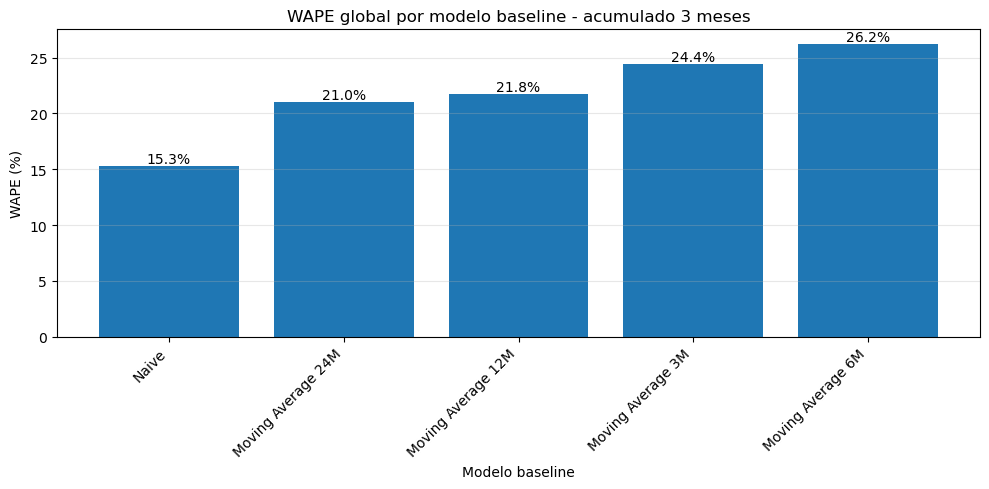

In [39]:
# ============================================================
# 33. Gráfica global de WAPE por modelo baseline
# ============================================================

df_plot_global = df_metricas_globales_baseline_3m.sort_values("WAPE")

plt.figure(figsize=(10, 5))

plt.bar(
    df_plot_global["modelo_baseline"],
    df_plot_global["WAPE"]
)

plt.title("WAPE global por modelo baseline - acumulado 3 meses")
plt.xlabel("Modelo baseline")
plt.ylabel("WAPE (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, valor in enumerate(df_plot_global["WAPE"]):
    plt.text(
        i,
        valor,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

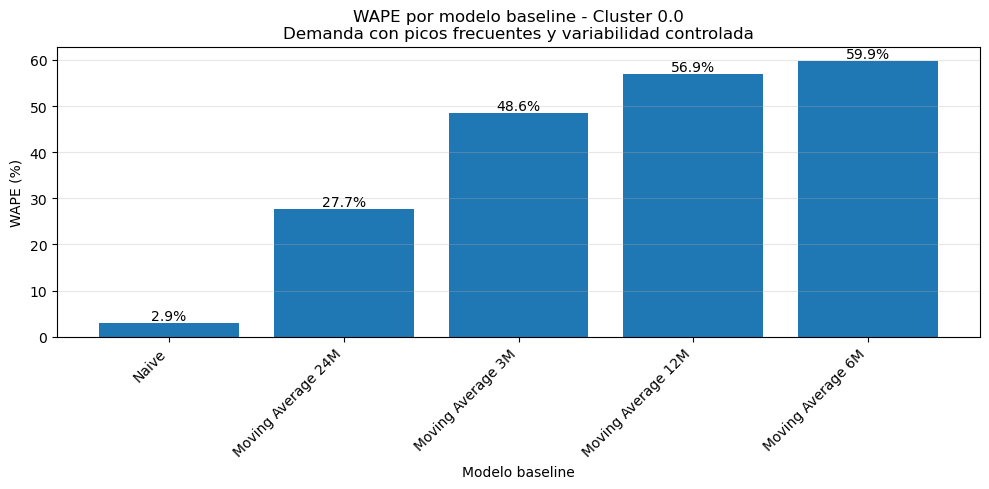

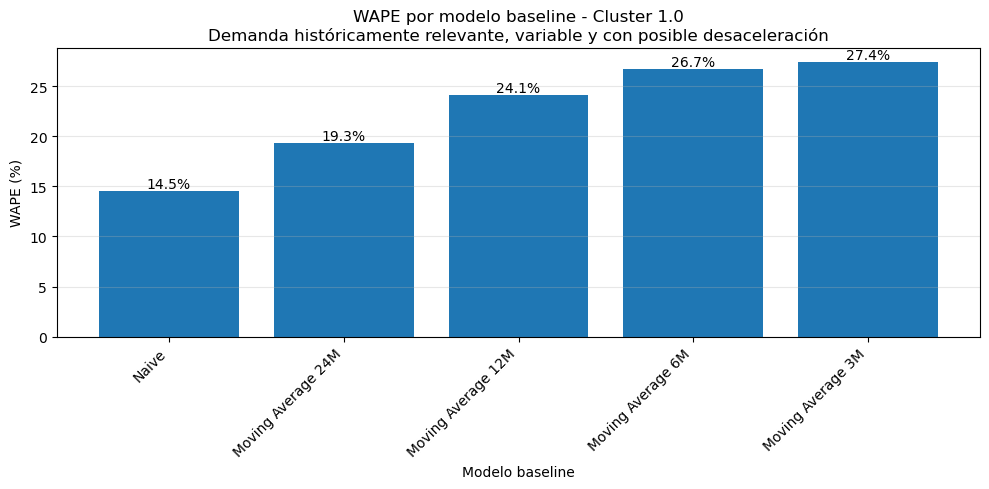

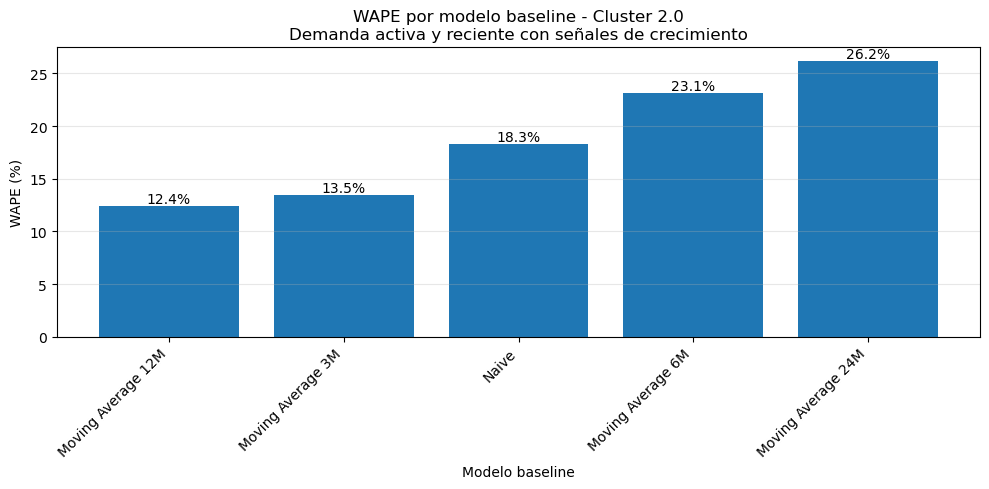

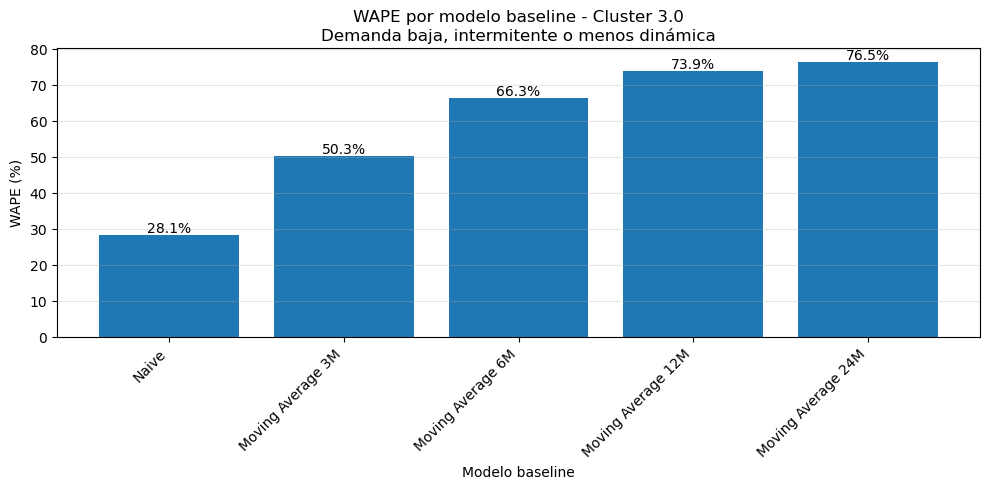

In [40]:
# ============================================================
# 34. Gráfica de WAPE por cluster y modelo
# ============================================================

for cluster in sorted(df_metricas_cluster_baseline_3m["cluster_kmeans_final"].unique()):
    
    df_plot_cluster = (
        df_metricas_cluster_baseline_3m[
            df_metricas_cluster_baseline_3m["cluster_kmeans_final"] == cluster
        ]
        .sort_values("WAPE")
        .copy()
    )
    
    descripcion = df_plot_cluster["descripcion_cluster"].iloc[0]
    
    plt.figure(figsize=(10, 5))
    
    plt.bar(
        df_plot_cluster["modelo_baseline"],
        df_plot_cluster["WAPE"]
    )
    
    plt.title(f"WAPE por modelo baseline - Cluster {cluster}\n{descripcion}")
    plt.xlabel("Modelo baseline")
    plt.ylabel("WAPE (%)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    
    for i, valor in enumerate(df_plot_cluster["WAPE"]):
        plt.text(
            i,
            valor,
            f"{valor:.1f}%",
            ha="center",
            va="bottom"
        )
    
    plt.tight_layout()
    plt.show()

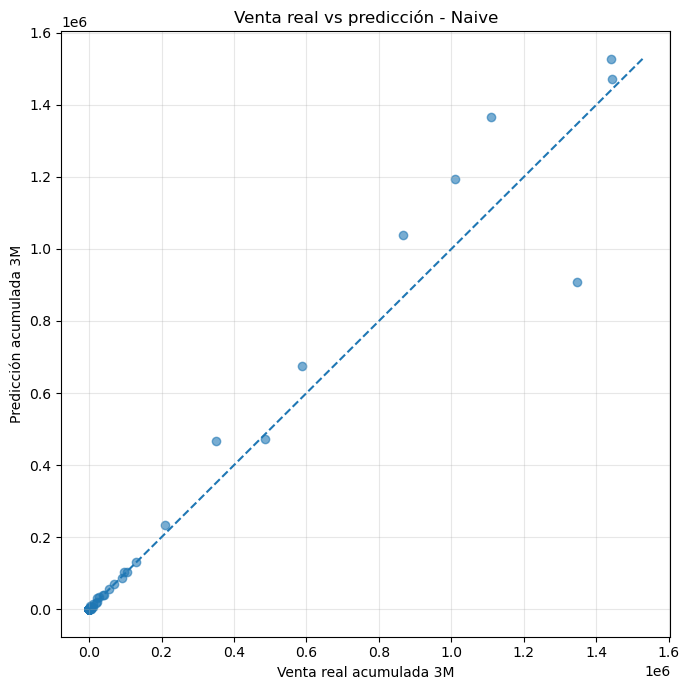

In [41]:

# 35. Real vs predicho del mejor baseline global
# ============================================================

mejor_modelo_global = df_mejor_baseline_global_3m["modelo_baseline"].iloc[0]

df_plot_real_pred = df_errores_baseline_3m[
    df_errores_baseline_3m["modelo_baseline"] == mejor_modelo_global
].copy()

plt.figure(figsize=(7, 7))

plt.scatter(
    df_plot_real_pred["venta_real_test_3m"],
    df_plot_real_pred["prediccion_test_3m"],
    alpha=0.6
)

max_valor = max(
    df_plot_real_pred["venta_real_test_3m"].max(),
    df_plot_real_pred["prediccion_test_3m"].max()
)

plt.plot(
    [0, max_valor],
    [0, max_valor],
    linestyle="--"
)

plt.title(f"Venta real vs predicción - {mejor_modelo_global}")
plt.xlabel("Venta real acumulada 3M")
plt.ylabel("Predicción acumulada 3M")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
df_series.info()

<class 'pandas.DataFrame'>
RangeIndex: 13950 entries, 0 to 13949
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   codigo_articulo              13950 non-null  str           
 1   descripcion_completa         13919 non-null  str           
 2   grupo_articulo               13950 non-null  str           
 3   categoria                    12741 non-null  str           
 4   subcategoria                 12741 non-null  str           
 5   tipo                         12586 non-null  str           
 6   unidad_medida_inventario     13950 non-null  str           
 7   marca_fabricante             13950 non-null  str           
 8   cluster_kmeans_final         13888 non-null  float64       
 9   descripcion_cluster          13888 non-null  str           
 10  modelos_candidatos_forecast  13888 non-null  str           
 11  modelo_forecast              13888 non-null  str    

In [43]:
# ============================================================
# 16. Creación de series temporales por artículo
# ============================================================
# Objetivo:
# Construir una estructura donde cada código de artículo tenga
# asociada su propia serie temporal mensual de ventas.
#
# Esta estructura será la base para generar inferencias individuales
# con modelos dummy y posteriormente con modelos avanzados.
# ============================================================
series_por_articulo = {}


#df_series.groupby("codigo_articulo").head()

for codigo, df_articulo in df_series.groupby("codigo_articulo"):
    serie = (
    df_articulo
    .sort_values("fecha_mes")
    .set_index("fecha_mes")["venta_mensual"]
    .asfreq("ME")
    )
    series_por_articulo[codigo] = serie
print("Cantidad de series temporales creadas:")
print(len(series_por_articulo))

Cantidad de series temporales creadas:
450


In [44]:
# ============================================================
# 17. Validación visual de una serie temporal individual
# ============================================================

codigo_ejemplo = list(series_por_articulo.keys())[0]

print("Código de ejemplo:")
print(codigo_ejemplo)

series_por_articulo[codigo_ejemplo]

Código de ejemplo:
0225-3M


fecha_mes
2024-01-31      0.0
2024-02-29      0.0
2024-03-31      0.0
2024-04-30      0.0
2024-05-31      0.0
2024-06-30      0.0
2024-07-31      0.0
2024-08-31     18.0
2024-09-30      0.0
2024-10-31      0.0
2024-11-30      0.0
2024-12-31      0.0
2025-01-31      0.0
2025-02-28    150.0
2025-03-31      0.0
2025-04-30      0.0
2025-05-31     10.0
2025-06-30      0.0
2025-07-31     14.0
2025-08-31      0.0
2025-09-30      0.0
2025-10-31      6.0
2025-11-30     12.0
2025-12-31      0.0
2026-01-31      0.0
2026-02-28     24.0
2026-03-31      0.0
2026-04-30      0.0
2026-05-31     24.0
2026-06-30      9.0
2026-07-31      0.0
Freq: ME, Name: venta_mensual, dtype: float64

In [45]:
series_por_articulo[codigo_ejemplo].index

DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31',
               '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31',
               '2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30', '2026-07-31'],
              dtype='datetime64[us]', name='fecha_mes', freq='ME')

In [46]:
# ============================================================
# 17.2 Función para definir intervalos train/test
# ============================================================
# Objetivo:
# Definir automáticamente el intervalo de entrenamiento y validación
# a partir de una serie temporal individual.
#
# Ejemplo:
# Si la serie termina en 2026-07 y meses_validacion = 3:
# - Train: 2024-01 a 2026-04
# - Test:  2026-05 a 2026-07
# ============================================================

def calcular_intervalos_train_test(serie, meses_validacion=6):
    """
    Calcula fechas de train y test para una serie temporal mensual.

    Parámetros:
    - serie: pd.Series con índice temporal mensual.
    - meses_validacion: cantidad de meses finales que se usarán como test.

    Retorna:
    - diccionario con fechas de inicio y fin de train/test.
    """

    serie = serie.sort_index().copy()

    fechas = pd.Series(serie.index).sort_values().reset_index(drop=True)

    if meses_validacion <= 0:
        raise ValueError("meses_validacion debe ser mayor que cero.")

    if meses_validacion >= len(fechas):
        raise ValueError(
            "meses_validacion no puede ser mayor o igual a la cantidad total de meses."
        )

    fechas_test = fechas.tail(meses_validacion)

    fecha_inicio_test = fechas_test.min()
    fecha_fin_test = fechas_test.max()

    fechas_train = fechas[fechas < fecha_inicio_test]

    fecha_inicio_train = fechas_train.min()
    fecha_fin_train = fechas_train.max()

    return {
        "fecha_inicio_train": fecha_inicio_train,
        "fecha_fin_train": fecha_fin_train,
        "fecha_inicio_test": fecha_inicio_test,
        "fecha_fin_test": fecha_fin_test,
        "fechas_test": list(fechas_test),
        "meses_train": len(fechas_train),
        "meses_test": len(fechas_test)
    }

In [47]:
# ============================================================
# 17.3 Función para calcular resumen de serie temporal
#      incluyendo separación train/test
# ============================================================

def calcular_resumen_serie_articulo(serie, meses_validacion=3):
    """
    Calcula estadísticas descriptivas para una serie temporal mensual,
    separando entrenamiento y validación.

    Parámetros:
    - serie: pd.Series con índice fecha_mes y valores de venta.
    - meses_validacion: cantidad de meses finales reservados como test.

    Retorna:
    - diccionario con métricas de la serie total, train y test.
    """

    serie = serie.sort_index().copy()

    intervalos = calcular_intervalos_train_test(
        serie=serie,
        meses_validacion=meses_validacion
    )

    fecha_inicio_train = intervalos["fecha_inicio_train"]
    fecha_fin_train = intervalos["fecha_fin_train"]
    fecha_inicio_test = intervalos["fecha_inicio_test"]
    fecha_fin_test = intervalos["fecha_fin_test"]

    serie_train = serie[
        (serie.index >= fecha_inicio_train) &
        (serie.index <= fecha_fin_train)
    ]

    serie_test = serie[
        (serie.index >= fecha_inicio_test) &
        (serie.index <= fecha_fin_test)
    ]

    resumen = {
        # Fechas
        "fecha_inicio_total": serie.index.min(),
        "fecha_fin_total": serie.index.max(),
        "fecha_inicio_train": fecha_inicio_train,
        "fecha_fin_train": fecha_fin_train,
        "fecha_inicio_test": fecha_inicio_test,
        "fecha_fin_test": fecha_fin_test,

        # Cantidad de meses
        "cantidad_meses_total": serie.shape[0],
        "cantidad_meses_train": serie_train.shape[0],
        "cantidad_meses_test": serie_test.shape[0],

        # Serie total
        #"venta_total": serie.sum(),
        #"venta_minima_total": serie.min(),
        "venta_maxima_total": serie.max(),
        #"venta_promedio_total": serie.mean(),
        #"venta_mediana_total": serie.median(),
        #"meses_con_venta_total": (serie > 0).sum(),
        #"meses_sin_venta_total": (serie == 0).sum(),

        # Train
        "venta_total_train": serie_train.sum(),
        #"venta_minima_train": serie_train.min(),
        #"venta_maxima_train": serie_train.max(),
        "venta_promedio_train": serie_train.mean(),
        #"venta_mediana_train": serie_train.median(),
        #"meses_con_venta_train": (serie_train > 0).sum(),
        #"meses_sin_venta_train": (serie_train == 0).sum(),

        # Test
        "venta_total_test": serie_test.sum(),
        #"venta_minima_test": serie_test.min(),
        #"venta_maxima_test": serie_test.max(),
        "venta_promedio_test": serie_test.mean(),
        #"venta_mediana_test": serie_test.median(),
        #"meses_con_venta_test": (serie_test > 0).sum(),
        #"meses_sin_venta_test": (serie_test == 0).sum(),

        # Promedios históricos calculados solo con train
        "promedio_train_ultimos_6m": serie_train.tail(6).mean(),
        "promedio_train_ultimos_12m": serie_train.tail(12).mean(),
        "promedio_train_ultimos_24m": serie_train.tail(24).mean(),

        # Proyección dummy acumulada para el horizonte de test
        "pred_promedio_6m_test": serie_train.tail(6).mean() * serie_test.shape[0],
        "pred_promedio_12m_test": serie_train.tail(12).mean() * serie_test.shape[0],
        "pred_promedio_24m_test": serie_train.tail(24).mean() * serie_test.shape[0],
    }

    return resumen

In [48]:
# ============================================================
# 17.4 Función para graficar serie temporal con train/test
# ============================================================

def graficar_serie_temporal_articulo(
    serie,
    codigo_articulo,
    descripcion_articulo=None,
    meses_validacion=3,
    mostrar_promedios=True,
    mostrar_etiquetas=True
):
    """
    Grafica una serie temporal mensual de ventas para un artículo,
    diferenciando visualmente train y test.

    Parámetros:
    - serie: pd.Series con índice fecha_mes y valores venta_mensual.
    - codigo_articulo: código del artículo.
    - descripcion_articulo: descripción opcional del artículo.
    - meses_validacion: cantidad de meses finales usados como test.
    - mostrar_promedios: si True, muestra promedios calculados solo con train.
    - mostrar_etiquetas: si True, muestra etiquetas en ventas > 0.
    """

    serie = serie.sort_index().copy()

    resumen = calcular_resumen_serie_articulo(
        serie=serie,
        meses_validacion=meses_validacion
    )

    fecha_inicio_train = resumen["fecha_inicio_train"]
    fecha_fin_train = resumen["fecha_fin_train"]
    fecha_inicio_test = resumen["fecha_inicio_test"]
    fecha_fin_test = resumen["fecha_fin_test"]

    serie_train = serie[
        (serie.index >= fecha_inicio_train) &
        (serie.index <= fecha_fin_train)
    ]

    serie_test = serie[
        (serie.index >= fecha_inicio_test) &
        (serie.index <= fecha_fin_test)
    ]

    fig, ax = plt.subplots(figsize=(17, 6))

    # Línea train
    ax.plot(
        serie_train.index,
        serie_train.values,
        marker="o",
        linewidth=1.8,
        label=f"Train: {fecha_inicio_train.strftime('%Y-%m')} a {fecha_fin_train.strftime('%Y-%m')}"
    )

    # Línea test
    ax.plot(
        serie_test.index,
        serie_test.values,
        marker="o",
        linewidth=2.2,
        label=f"Test: {fecha_inicio_test.strftime('%Y-%m')} a {fecha_fin_test.strftime('%Y-%m')}"
    )

    # Línea vertical para separar train/test
    ax.axvline(
        fecha_inicio_test,
        linestyle="--",
        linewidth=1.5,
        label="Inicio validación"
    )

    # Etiquetas numéricas solo para ventas distintas de cero
    if mostrar_etiquetas:
        for fecha, valor in serie.items():
            if valor != 0:
                ax.text(
                    fecha,
                    valor,
                    f"{valor:,.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    # Líneas horizontales de promedios calculados solo con train
    if mostrar_promedios:
        ax.axhline(
            resumen["promedio_train_ultimos_6m"],
            linestyle=":",
            linewidth=1.3,
            label=f"Promedio train últimos 6M: {resumen['promedio_train_ultimos_6m']:,.2f}"
        )

        ax.axhline(
            resumen["promedio_train_ultimos_12m"],
            linestyle=":",
            linewidth=1.3,
            label=f"Promedio train últimos 12M: {resumen['promedio_train_ultimos_12m']:,.2f}"
        )

        ax.axhline(
            resumen["promedio_train_ultimos_24m"],
            linestyle=":",
            linewidth=1.3,
            label=f"Promedio train últimos 24M: {resumen['promedio_train_ultimos_24m']:,.2f}"
        )

    # Marcar máximo total
    fecha_max = serie.idxmax()
    valor_max = serie.max()

    ax.scatter(
        fecha_max,
        valor_max,
        s=90,
        zorder=5,
        label=f"Máximo total: {valor_max:,.0f}"
    )

    # Eje X con todos los meses en formato YYYY-MM
    etiquetas_meses = [
        fecha.strftime("%Y-%m")
        for fecha in serie.index
    ]

    ax.set_xticks(serie.index)
    ax.set_xticklabels(
        etiquetas_meses,
        rotation=90,
        ha="center"
    )

    if descripcion_articulo:
        titulo = f"Serie temporal mensual de ventas - {codigo_articulo}\n{descripcion_articulo}"
    else:
        titulo = f"Serie temporal mensual de ventas - {codigo_articulo}"

    ax.set_title(titulo)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Venta mensual")

    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

    return resumen

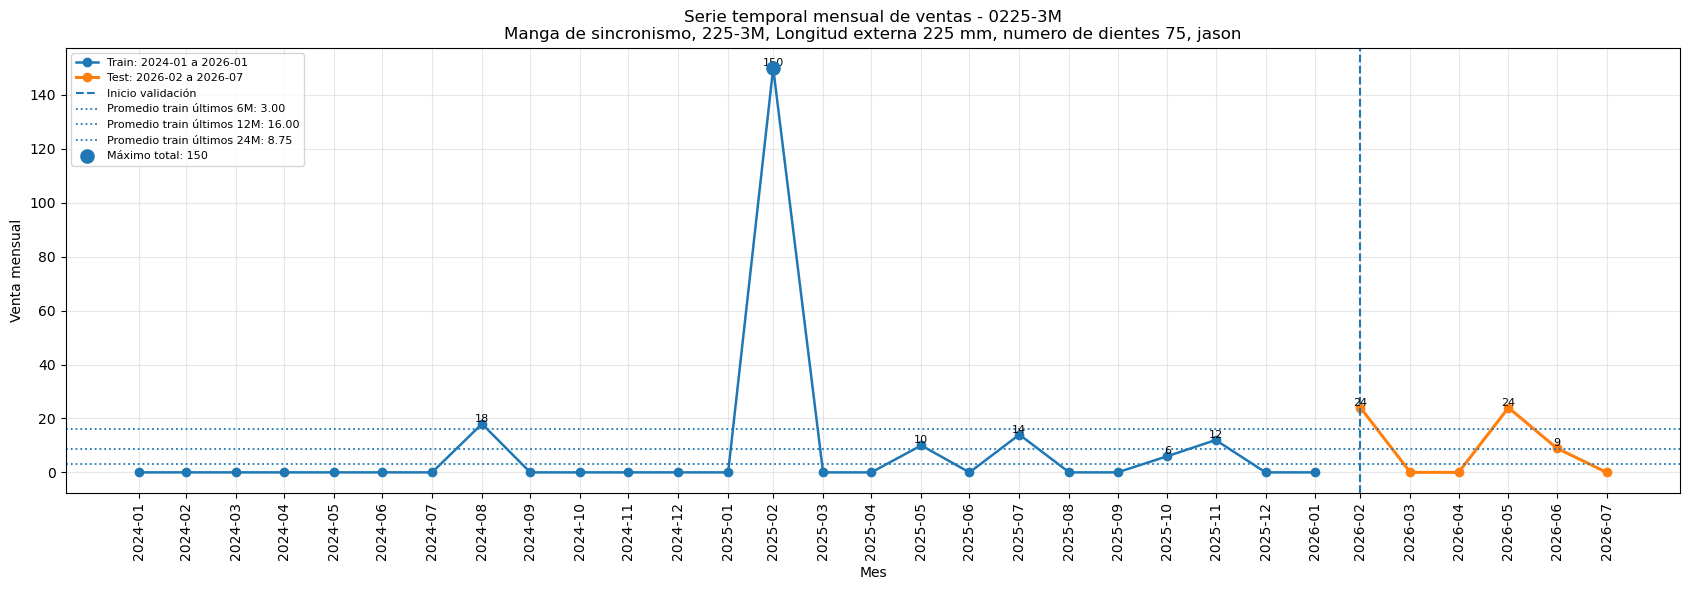

,metrica,valor
0,fecha_inicio_total,2024-01-31 00:00:00
1,fecha_fin_total,2026-07-31 00:00:00
2,fecha_inicio_train,2024-01-31 00:00:00
3,fecha_fin_train,2026-01-31 00:00:00
4,fecha_inicio_test,2026-02-28 00:00:00
5,fecha_fin_test,2026-07-31 00:00:00
6,cantidad_meses_total,31
7,cantidad_meses_train,25
8,cantidad_meses_test,6
9,venta_maxima_total,150.0


In [49]:
codigo_ejemplo = "0225-3M"

serie_ejemplo = series_por_articulo[codigo_ejemplo]

descripcion_ejemplo = (
    df_series[df_series["codigo_articulo"] == codigo_ejemplo]
    ["descripcion_completa"]
    .dropna()
    .iloc[0]
)

resumen_grafica = graficar_serie_temporal_articulo(
    serie=serie_ejemplo,
    codigo_articulo=codigo_ejemplo,
    descripcion_articulo=descripcion_ejemplo,
    meses_validacion=6,
    mostrar_promedios=True,
    mostrar_etiquetas=True
)

df_resumen_grafica = pd.DataFrame(
    resumen_grafica.items(),
    columns=["metrica", "valor"]
)

df_resumen_grafica

In [50]:
# ============================================================
# 17.7 Función para obtener trazabilidad del artículo
# ============================================================
# Objetivo:
# Recuperar la información maestra y de clusterización de un artículo
# para mantener trazabilidad entre:
# - serie temporal individual
# - características del artículo
# - cluster asignado
# - descripción del cluster
# ============================================================

def obtener_trazabilidad_articulo(codigo_articulo, df_base):
    """
    Obtiene la información maestra y de clusterización de un artículo.

    Parámetros:
    - codigo_articulo: código del artículo a consultar.
    - df_base: dataframe en formato largo, normalmente df_series.

    Retorna:
    - DataFrame con una fila y las columnas de trazabilidad del artículo.
    """

    columnas_trazabilidad = [
        "codigo_articulo",
        "descripcion_completa",
        "grupo_articulo",
        "categoria",
        "subcategoria",
        "tipo",
        "marca_fabricante",
        "unidad_medida_inventario",
        "cluster_kmeans_final",
        "descripcion_cluster"
    ]

    columnas_disponibles = [
        col for col in columnas_trazabilidad
        if col in df_base.columns
    ]

    df_trazabilidad = (
        df_base[df_base["codigo_articulo"] == codigo_articulo]
        [columnas_disponibles]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if df_trazabilidad.empty:
        raise ValueError(
            f"No se encontró información para el artículo: {codigo_articulo}"
        )

    if df_trazabilidad.shape[0] > 1:
        print(
            f"⚠️ Advertencia: el artículo {codigo_articulo} tiene más de una combinación "
            "de datos maestros o cluster. Revisar trazabilidad."
        )

    return df_trazabilidad

In [51]:
# ============================================================
# 17.9 Mostrar trazabilidad resumida del artículo
# ============================================================

def mostrar_trazabilidad_articulo(codigo_articulo, df_base):
    """
    Imprime en pantalla la trazabilidad principal de un artículo.
    """

    df_trazabilidad = obtener_trazabilidad_articulo(
        codigo_articulo=codigo_articulo,
        df_base=df_base
    )

    fila = df_trazabilidad.iloc[0]

    print("=" * 80)
    print("TRAZABILIDAD DEL ARTÍCULO")
    print("=" * 80)
    print(f"Código artículo: {fila.get('codigo_articulo', 'N/D')}")
    print(f"Descripción: {fila.get('descripcion_completa', 'N/D')}")
    print(f"Grupo artículo: {fila.get('grupo_articulo', 'N/D')}")
    print(f"Categoría: {fila.get('categoria', 'N/D')}")
    print(f"Subcategoría: {fila.get('subcategoria', 'N/D')}")
    print(f"Tipo: {fila.get('tipo', 'N/D')}")
    print(f"Marca fabricante: {fila.get('marca_fabricante', 'N/D')}")
    print(f"Unidad inventario: {fila.get('unidad_medida_inventario', 'N/D')}")
    print("-" * 80)
    print(f"Cluster K-Means: {fila.get('cluster_kmeans_final', 'N/D')}")
    print(f"Descripción cluster: {fila.get('descripcion_cluster', 'N/D')}")
    print("=" * 80)

In [52]:
# ============================================================
# 17.6 Resumen + gráfica de serie temporal individual
# ============================================================

def analizar_serie_temporal_articulo(codigo_articulo, df_base=df_series):
    """
    Calcula resumen estadístico y grafica la serie temporal
    mensual de ventas de un artículo.
    """

    serie = series_por_articulo[codigo_articulo]

    descripcion = (
        df_series[df_series["codigo_articulo"] == codigo_articulo]
        ["descripcion_completa"]
        .dropna()
        .iloc[0]
    )

    resumen = graficar_serie_temporal_articulo(
    serie=serie,
    codigo_articulo=codigo_articulo,
    descripcion_articulo=descripcion,
    meses_validacion=6,
    mostrar_promedios=True,
    mostrar_etiquetas=True
    )

    mostrar_trazabilidad_articulo(codigo_articulo, df_base)

    df_resumen = pd.DataFrame(
        resumen.items(),
        columns=["metrica", "valor"]
    )

    return df_resumen

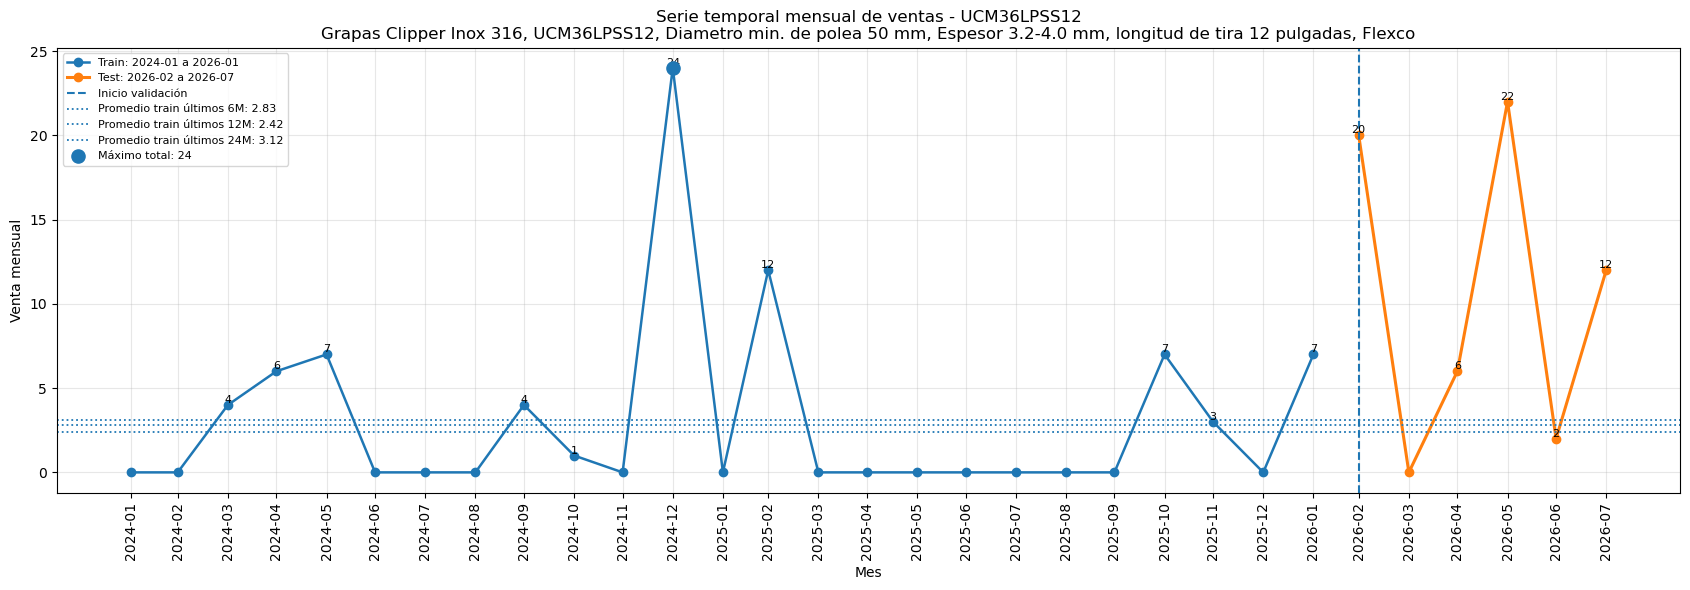

TRAZABILIDAD DEL ARTÍCULO
Código artículo: UCM36LPSS12
Descripción: Grapas Clipper Inox 316, UCM36LPSS12, Diametro min. de polea 50 mm, Espesor 3.2-4.0 mm, longitud de tira 12 pulgadas, Flexco
Grupo artículo: GRAPAS
Categoría: Grapas
Subcategoría: Servicio liviano
Tipo: Clipper
Marca fabricante: FLEXCO
Unidad inventario: UNI
--------------------------------------------------------------------------------
Cluster K-Means: 2.0
Descripción cluster: Demanda activa y reciente con señales de crecimiento


,metrica,valor
0,fecha_inicio_total,2024-01-31 00:00:00
1,fecha_fin_total,2026-07-31 00:00:00
2,fecha_inicio_train,2024-01-31 00:00:00
3,fecha_fin_train,2026-01-31 00:00:00
4,fecha_inicio_test,2026-02-28 00:00:00
5,fecha_fin_test,2026-07-31 00:00:00
6,cantidad_meses_total,31
7,cantidad_meses_train,25
8,cantidad_meses_test,6
9,venta_maxima_total,24.0


In [53]:
analizar_serie_temporal_articulo("UCM36LPSS12")

In [54]:

# 19. Función para generar predicciones dummy por artículo
# ============================================================
# Objetivo:
# Para una serie temporal individual:
# - separar train y test
# - calcular promedios históricos usando solo train
# - proyectar esos promedios hacia el período test
# - calcular venta real acumulada del test
# ============================================================

def generar_predicciones_dummy_promedio_train(
    codigo,
    serie,
    meses_validacion=6,
    ventanas_promedio=[3, 6, 12, 24]
):
    """
    Genera predicciones dummy basadas en promedio del período train.

    Parámetros:
    - serie: pd.Series con índice fecha_mes y valores de venta mensual.
    - codigo_articulo: código del artículo.
    - meses_validacion: cantidad de meses finales usados como test.
    - ventanas_promedio: ventanas históricas para calcular promedio.

    Retorna:
    - DataFrame con una fila por artículo y modelo dummy.
    """
    serie = serie.sort_index().copy()

    intervalos = calcular_intervalos_train_test(
        serie=serie,
        meses_validacion=meses_validacion
    )

    fecha_inicio_train = intervalos["fecha_inicio_train"]
    fecha_fin_train = intervalos["fecha_fin_train"]
    fecha_inicio_test = intervalos["fecha_inicio_test"]
    fecha_fin_test = intervalos["fecha_fin_test"]

    serie_train = serie[
        (serie.index >= fecha_inicio_train) &
        (serie.index <= fecha_fin_train)
    ]

    serie_test = serie[
        (serie.index >= fecha_inicio_test) &
        (serie.index <= fecha_fin_test)
    ]

    venta_real_test = serie_test.sum()
    cantidad_meses_test = serie_test.shape[0]

    resultados = []

    # --------------------------------------------------------
    # Modelo dummy 1: Naive fijo
    # --------------------------------------------------------
    # Usa la última venta conocida del train y la proyecta
    # para todos los meses del test.
    # --------------------------------------------------------

    ultima_venta_train = serie_train.iloc[-1]

    pred_naive = ultima_venta_train * cantidad_meses_test

    resultados.append({
        "codigo_articulo": codigo,
        "modelo_dummy": "Naive fijo última venta",
        "ventana_promedio_meses": 1,
        "fecha_inicio_train": fecha_inicio_train,
        "fecha_fin_train": fecha_fin_train,
        "fecha_inicio_test": fecha_inicio_test,
        "fecha_fin_test": fecha_fin_test,
        "meses_train": serie_train.shape[0],
        "meses_test": cantidad_meses_test,
        "venta_real_test": venta_real_test,
        "promedio_mensual_train": ultima_venta_train,
        "prediccion_test": pred_naive
    })

    # --------------------------------------------------------
    # Modelos dummy por promedio histórico fijo
    # --------------------------------------------------------
    # Calcula promedio mensual de los últimos N meses del train
    # y lo multiplica por los meses del test.
    # --------------------------------------------------------

    for ventana in ventanas_promedio:

        serie_ventana = serie_train.tail(ventana)

        promedio_ventana = serie_ventana.mean()
        meses_usados = serie_ventana.shape[0]

        prediccion = promedio_ventana * cantidad_meses_test

        resultados.append({
            "codigo_articulo": codigo,
            "modelo_dummy": f"Promedio train últimos {ventana}M",
            "ventana_promedio_meses": ventana,
            "fecha_inicio_train": fecha_inicio_train,
            "fecha_fin_train": fecha_fin_train,
            "fecha_inicio_test": fecha_inicio_test,
            "fecha_fin_test": fecha_fin_test,
            "meses_train": serie_train.shape[0],
            "meses_test": cantidad_meses_test,
            "meses_usados_promedio": meses_usados,
            "venta_real_test": venta_real_test,
            "promedio_mensual_train": promedio_ventana,
            "prediccion_test": prediccion
        })

    return pd.DataFrame(resultados)

In [55]:
generar_predicciones_dummy_promedio_train("0225-3M", series_por_articulo["0225-3M"])


,codigo_articulo,modelo_dummy,ventana_promedio_meses,fecha_inicio_train,fecha_fin_train,fecha_inicio_test,fecha_fin_test,meses_train,meses_test,venta_real_test,promedio_mensual_train,prediccion_test,meses_usados_promedio
0,0225-3M,Naive fijo última venta,1,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,0.00,0.0,NaN
1,0225-3M,Promedio train últimos 3M,3,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,4.00,24.0,3.0
2,0225-3M,Promedio train últimos 6M,6,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,3.00,18.0,6.0
3,0225-3M,Promedio train últimos 12M,12,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,16.00,96.0,12.0
4,0225-3M,Promedio train últimos 24M,24,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,8.75,52.5,24.0


In [56]:
# ============================================================
# 20. Generar predicciones dummy para todos los artículos
# ============================================================

resultados_dummy = []

for codigo_articulo, serie in series_por_articulo.items():

    df_pred_dummy_articulo = generar_predicciones_dummy_promedio_train(
        codigo=codigo_articulo,
        serie=serie,
        meses_validacion=6,
        ventanas_promedio=[3, 6, 12, 24]
    )

    resultados_dummy.append(df_pred_dummy_articulo)

df_predicciones_dummy = pd.concat(
    resultados_dummy,
    ignore_index=True
)

print("Dimensiones de predicciones dummy:")
print(df_predicciones_dummy.shape)

df_predicciones_dummy.head(20)

Dimensiones de predicciones dummy:
(2250, 13)


,codigo_articulo,modelo_dummy,ventana_promedio_meses,fecha_inicio_train,fecha_fin_train,fecha_inicio_test,fecha_fin_test,meses_train,meses_test,venta_real_test,promedio_mensual_train,prediccion_test,meses_usados_promedio
0,0225-3M,Naive fijo última venta,1,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,0.000000,0.00,NaN
1,0225-3M,Promedio train últimos 3M,3,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,4.000000,24.00,3.0
2,0225-3M,Promedio train últimos 6M,6,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,3.000000,18.00,6.0
3,0225-3M,Promedio train últimos 12M,12,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,16.000000,96.00,12.0
4,0225-3M,Promedio train últimos 24M,24,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,8.750000,52.50,24.0
5,0270H,Naive fijo última venta,1,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,907.0,150.000000,900.00,NaN
6,0270H,Promedio train últimos 3M,3,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,907.0,325.000000,1950.00,3.0
7,0270H,Promedio train últimos 6M,6,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,907.0,177.166667,1063.00,6.0
8,0270H,Promedio train últimos 12M,12,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,907.0,201.083333,1206.50,12.0
9,0270H,Promedio train últimos 24M,24,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,907.0,121.458333,728.75,24.0


In [57]:
# ============================================================
# 21. Agregar trazabilidad de artículo y cluster
# ============================================================

columnas_trazabilidad = [
    "codigo_articulo",
    "descripcion_completa",
    "grupo_articulo",
    "categoria",
    "subcategoria",
    "tipo",
    "marca_fabricante",
    "unidad_medida_inventario",
    "cluster_kmeans_final",
    "descripcion_cluster"
]

df_trazabilidad_articulos = (
    df_series[columnas_trazabilidad]
    .drop_duplicates(subset=["codigo_articulo"])
    .copy()
)

df_predicciones_dummy = df_predicciones_dummy.merge(
    df_trazabilidad_articulos,
    on="codigo_articulo",
    how="left",
    validate="many_to_one"
)

print("Dimensiones con trazabilidad:")
print(df_predicciones_dummy.shape)

df_predicciones_dummy.head()

Dimensiones con trazabilidad:
(2250, 22)


,codigo_articulo,modelo_dummy,ventana_promedio_meses,fecha_inicio_train,fecha_fin_train,fecha_inicio_test,fecha_fin_test,meses_train,meses_test,venta_real_test,...,meses_usados_promedio,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster
0,0225-3M,Naive fijo última venta,1,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,...,NaN,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c..."
1,0225-3M,Promedio train últimos 3M,3,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,...,3.0,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c..."
2,0225-3M,Promedio train últimos 6M,6,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,...,6.0,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c..."
3,0225-3M,Promedio train últimos 12M,12,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,...,12.0,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c..."
4,0225-3M,Promedio train últimos 24M,24,2024-01-31,2026-01-31,2026-02-28,2026-07-31,25,6,57.0,...,24.0,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c..."


In [58]:
# ============================================================
# 22. Calcular errores por artículo y modelo dummy
# ============================================================

df_predicciones_dummy["error"] = (
    df_predicciones_dummy["venta_real_test"] -
    df_predicciones_dummy["prediccion_test"]
)

df_predicciones_dummy["error_absoluto"] = (
    df_predicciones_dummy["error"].abs()
)

df_predicciones_dummy["error_cuadratico"] = (
    df_predicciones_dummy["error"] ** 2
)

df_predicciones_dummy["sesgo_tipo"] = np.where(
    df_predicciones_dummy["error"] > 0,
    "Subestimación",
    np.where(
        df_predicciones_dummy["error"] < 0,
        "Sobreestimación",
        "Exacto"
    )
)

df_predicciones_dummy[
    [
        "codigo_articulo",
        "cluster_kmeans_final",
        "modelo_dummy",
        "venta_real_test",
        "prediccion_test",
        "error",
        "error_absoluto",
        "sesgo_tipo"
    ]
].head(20)

,codigo_articulo,cluster_kmeans_final,modelo_dummy,venta_real_test,prediccion_test,error,error_absoluto,sesgo_tipo
0,0225-3M,1.0,Naive fijo última venta,57.0,0.00,57.00,57.00,Subestimación
1,0225-3M,1.0,Promedio train últimos 3M,57.0,24.00,33.00,33.00,Subestimación
2,0225-3M,1.0,Promedio train últimos 6M,57.0,18.00,39.00,39.00,Subestimación
3,0225-3M,1.0,Promedio train últimos 12M,57.0,96.00,-39.00,39.00,Sobreestimación
4,0225-3M,1.0,Promedio train últimos 24M,57.0,52.50,4.50,4.50,Subestimación
5,0270H,2.0,Naive fijo última venta,907.0,900.00,7.00,7.00,Subestimación
6,0270H,2.0,Promedio train últimos 3M,907.0,1950.00,-1043.00,1043.00,Sobreestimación
7,0270H,2.0,Promedio train últimos 6M,907.0,1063.00,-156.00,156.00,Sobreestimación
8,0270H,2.0,Promedio train últimos 12M,907.0,1206.50,-299.50,299.50,Sobreestimación
9,0270H,2.0,Promedio train últimos 24M,907.0,728.75,178.25,178.25,Subestimación


In [59]:
# ============================================================
# 24. Métricas globales por modelo dummy
# ============================================================

resultados_metricas_dummy_global = []
meses_validacion=6
for modelo in sorted(df_predicciones_dummy["modelo_dummy"].unique()):

    df_eval = df_predicciones_dummy[
        df_predicciones_dummy["modelo_dummy"] == modelo
    ].dropna(
        subset=["venta_real_test", "prediccion_test"]
    ).copy()

    metricas = calcular_metricas_forecast(
        y_real=df_eval["venta_real_test"],
        y_pred=df_eval["prediccion_test"]
    )

    metricas["modelo_dummy"] = modelo
    metricas["horizonte_evaluacion"] = f"acumulado_{meses_validacion}_meses"
    metricas["cantidad_articulos"] = df_eval["codigo_articulo"].nunique()
    metricas["fecha_inicio_test"] = df_eval["fecha_inicio_test"].iloc[0]
    metricas["fecha_fin_test"] = df_eval["fecha_fin_test"].iloc[0]

    resultados_metricas_dummy_global.append(metricas)

df_metricas_dummy_global = pd.DataFrame(resultados_metricas_dummy_global)

df_metricas_dummy_global = (
    df_metricas_dummy_global[
        [
            "modelo_dummy",
            "horizonte_evaluacion",
            "cantidad_articulos",
            "fecha_inicio_test",
            "fecha_fin_test",
            "venta_real_total",
            "prediccion_total",
            "error_absoluto_total",
            "MAE",
            "RMSE",
            # "sMAPE",
            "WAPE",
            "Bias",
            # "Bias_total",
            "Bias_pct"
        ]
    ]
    .round(2)
    .sort_values("WAPE")
)

df_metricas_dummy_global

C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_12080\511498697.py:50: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,modelo_dummy,horizonte_evaluacion,cantidad_articulos,fecha_inicio_test,fecha_fin_test,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
2,Promedio train últimos 24M,acumulado_6_meses,450,2026-02-28,2026-07-31,9655948.7,9159275.32,2156209.37,4791.58,38505.39,22.33,1103.72,5.14
1,Promedio train últimos 12M,acumulado_6_meses,450,2026-02-28,2026-07-31,9655948.7,8596675.20,2209136.64,4909.19,47025.62,22.88,2353.94,10.97
4,Promedio train últimos 6M,acumulado_6_meses,450,2026-02-28,2026-07-31,9655948.7,9386711.43,3383563.13,7519.03,66660.77,35.04,598.31,2.79
3,Promedio train últimos 3M,acumulado_6_meses,450,2026-02-28,2026-07-31,9655948.7,8870976.98,3680394.40,8178.65,64050.46,38.12,1744.38,8.13
0,Naive fijo última venta,acumulado_6_meses,450,2026-02-28,2026-07-31,9655948.7,8722731.18,5707235.58,12682.75,92061.10,59.11,2073.82,9.66


In [60]:
# ============================================================
# 25. Métricas por cluster y modelo dummy
# ============================================================

resultados_metricas_dummy_cluster = []

for cluster in sorted(df_predicciones_dummy["cluster_kmeans_final"].dropna().unique()):

    for modelo in sorted(df_predicciones_dummy["modelo_dummy"].unique()):

        df_eval = df_predicciones_dummy[
            (df_predicciones_dummy["cluster_kmeans_final"] == cluster) &
            (df_predicciones_dummy["modelo_dummy"] == modelo)
        ].dropna(
            subset=["venta_real_test", "prediccion_test"]
        ).copy()

        metricas = calcular_metricas_forecast(
            y_real=df_eval["venta_real_test"],
            y_pred=df_eval["prediccion_test"]
        )

        metricas["cluster_kmeans_final"] = cluster
        metricas["descripcion_cluster"] = df_eval["descripcion_cluster"].iloc[0]
        metricas["modelo_dummy"] = modelo
        metricas["horizonte_evaluacion"] = f"acumulado_{meses_validacion}_meses"
        metricas["cantidad_articulos"] = df_eval["codigo_articulo"].nunique()

        resultados_metricas_dummy_cluster.append(metricas)

df_metricas_dummy_cluster = pd.DataFrame(resultados_metricas_dummy_cluster)

df_metricas_dummy_cluster = (
    df_metricas_dummy_cluster[
        [
            "cluster_kmeans_final",
            "descripcion_cluster",
            "modelo_dummy",
            "horizonte_evaluacion",
            "cantidad_articulos",
            "venta_real_total",
            "prediccion_total",
            "error_absoluto_total",
            "MAE",
            "RMSE",
            # "sMAPE",
            "WAPE",
            "Bias",
            # "Bias_total",
            "Bias_pct"
        ]
    ]
    .round(2)
    .sort_values(["cluster_kmeans_final", "WAPE"])
)

df_metricas_dummy_cluster

,cluster_kmeans_final,descripcion_cluster,modelo_dummy,horizonte_evaluacion,cantidad_articulos,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
2,0.0,Demanda con picos frecuentes y variabilidad co...,Promedio train últimos 24M,acumulado_6_meses,165,107815.94,126280.06,19424.62,117.72,1338.34,18.02,-111.90,-17.13
1,0.0,Demanda con picos frecuentes y variabilidad co...,Promedio train últimos 12M,acumulado_6_meses,165,107815.94,146241.39,39713.45,240.69,2876.86,36.83,-232.88,-35.64
4,0.0,Demanda con picos frecuentes y variabilidad co...,Promedio train últimos 6M,acumulado_6_meses,165,107815.94,166965.24,60683.30,367.78,4502.11,56.28,-358.48,-54.86
3,0.0,Demanda con picos frecuentes y variabilidad co...,Promedio train últimos 3M,acumulado_6_meses,165,107815.94,213924.76,108342.82,656.62,8184.34,100.49,-643.08,-98.42
0,0.0,Demanda con picos frecuentes y variabilidad co...,Naive fijo última venta,acumulado_6_meses,165,107815.94,6074.10,109977.24,666.53,8110.50,102.00,616.62,94.37
7,1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 24M,acumulado_6_meses,60,7294517.78,7450731.80,1418002.80,23633.38,88836.46,19.44,-2603.57,-2.14
6,1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 12M,acumulado_6_meses,60,7294517.78,6383887.40,1745129.77,29085.50,126593.16,23.92,15177.17,12.48
9,1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 6M,acumulado_6_meses,60,7294517.78,6387248.63,2557593.47,42626.56,175103.75,35.06,15121.15,12.44
8,1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 3M,acumulado_6_meses,60,7294517.78,5982435.26,2679981.28,44666.35,165126.41,36.74,21868.04,17.99
5,1.0,"Demanda históricamente relevante, variable y c...",Naive fijo última venta,acumulado_6_meses,60,7294517.78,5238124.20,3832692.30,63878.20,219591.60,52.54,34273.23,28.19


In [61]:
# ============================================================
# 26. Mejor modelo dummy global
# ============================================================

df_mejor_dummy_global = (
    df_metricas_dummy_global
    .sort_values("WAPE")
    .head(1)
    .reset_index(drop=True)
)

df_mejor_dummy_global

,modelo_dummy,horizonte_evaluacion,cantidad_articulos,fecha_inicio_test,fecha_fin_test,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
0,Promedio train últimos 24M,acumulado_6_meses,450,2026-02-28,2026-07-31,9655948.7,9159275.32,2156209.37,4791.58,38505.39,22.33,1103.72,5.14


In [62]:
# ============================================================
# 27. Mejor modelo dummy por cluster
# ============================================================

df_mejor_dummy_por_cluster = (
    df_metricas_dummy_cluster
    .sort_values(["cluster_kmeans_final", "WAPE"])
    .groupby("cluster_kmeans_final")
    .head(1)
    .reset_index(drop=True)
)

df_mejor_dummy_por_cluster

,cluster_kmeans_final,descripcion_cluster,modelo_dummy,horizonte_evaluacion,cantidad_articulos,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,Bias,Bias_pct
0,0.0,Demanda con picos frecuentes y variabilidad co...,Promedio train últimos 24M,acumulado_6_meses,165,107815.94,126280.06,19424.62,117.72,1338.34,18.02,-111.90,-17.13
1,1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 24M,acumulado_6_meses,60,7294517.78,7450731.80,1418002.80,23633.38,88836.46,19.44,-2603.57,-2.14
2,2.0,Demanda activa y reciente con señales de creci...,Promedio train últimos 12M,acumulado_6_meses,74,2251679.48,2063533.50,422553.08,5710.18,20865.91,18.77,2542.51,8.36
3,3.0,"Demanda baja, intermitente o menos dinámica",Promedio train últimos 24M,acumulado_6_meses,149,1925.50,3026.61,1694.40,11.37,25.98,88.00,-7.39,-57.19


In [63]:
# ============================================================
# 28. Ranking de artículos con mayor error absoluto
# ============================================================

df_top_errores_dummy = (
    df_predicciones_dummy
    .sort_values("error_absoluto", ascending=False)
    [
        [
            "codigo_articulo",
            "descripcion_completa",
            "cluster_kmeans_final",
            "descripcion_cluster",
            "modelo_dummy",
            "venta_real_test",
            "prediccion_test",
            "error",
            "error_absoluto",
            "sesgo_tipo"
        ]
    ]
)

df_top_errores_dummy.head(30)

,codigo_articulo,descripcion_completa,cluster_kmeans_final,descripcion_cluster,modelo_dummy,venta_real_test,prediccion_test,error,error_absoluto,sesgo_tipo
1792,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 6M,1346304.76,1.527203e+05,1.193584e+06,1.193584e+06,Subestimación
1790,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Naive fijo última venta,1346304.76,1.579410e+05,1.188364e+06,1.188364e+06,Subestimación
1791,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 3M,1346304.76,2.709420e+05,1.075363e+06,1.075363e+06,Subestimación
1793,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 12M,1346304.76,4.299385e+05,9.163663e+05,9.163663e+05,Subestimación
2240,W8,"Cinta para husos, Habasit, W-8",1.0,"Demanda históricamente relevante, variable y c...",Naive fijo última venta,1440245.82,5.243986e+05,9.158472e+05,9.158472e+05,Subestimación
1675,HS-5GI,Faja Habasit,2.0,Demanda activa y reciente con señales de creci...,Naive fijo última venta,866605.69,1.654455e+06,-7.878493e+05,7.878493e+05,Sobreestimación
1794,P25-75A,"Banda Transportadora YL, color verde oscuro",1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 24M,1346304.76,7.158386e+05,6.304661e+05,6.304661e+05,Subestimación
1780,P22-07N,"Banda transportadora servicio liviano, Yongli,...",1.0,"Demanda históricamente relevante, variable y c...",Naive fijo última venta,1108562.32,1.637539e+06,-5.289765e+05,5.289765e+05,Sobreestimación
1765,NAJ-8EEDV,"Banda transportadora ligera, Habasit, NAJ-8EED...",2.0,Demanda activa y reciente con señales de creci...,Naive fijo última venta,349829.67,8.553655e+05,-5.055359e+05,5.055359e+05,Sobreestimación
1451,A200COS-B,"Banda transportadora de alta resistencia, Haba...",1.0,"Demanda históricamente relevante, variable y c...",Promedio train últimos 3M,486453.24,2.520000e+03,4.839332e+05,4.839332e+05,Subestimación


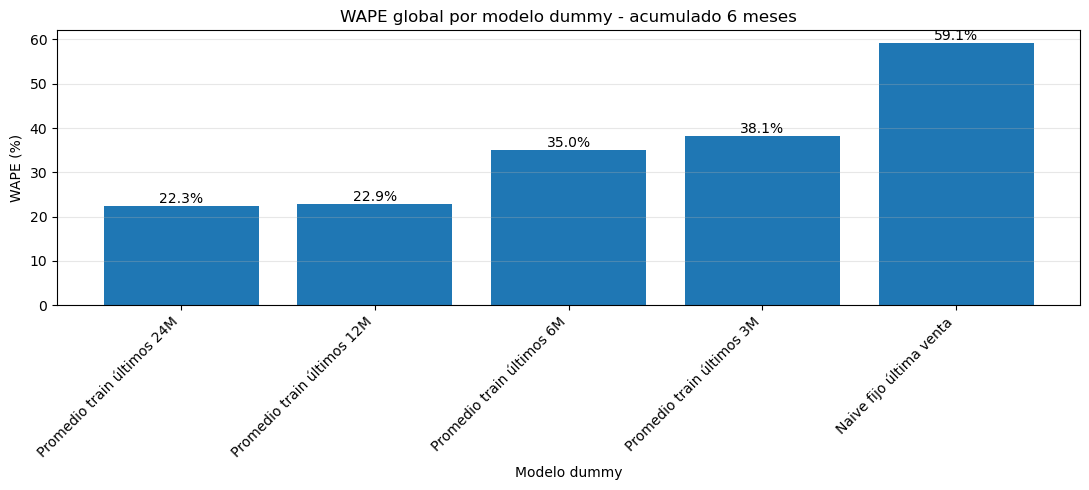

In [64]:
# ============================================================
# 29. Gráfica global de WAPE por modelo dummy
# ============================================================

df_plot_global_dummy = df_metricas_dummy_global.sort_values("WAPE")

plt.figure(figsize=(11, 5))

plt.bar(
    df_plot_global_dummy["modelo_dummy"],
    df_plot_global_dummy["WAPE"]
)

plt.title(f"WAPE global por modelo dummy - acumulado {meses_validacion} meses")
plt.xlabel("Modelo dummy")
plt.ylabel("WAPE (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, valor in enumerate(df_plot_global_dummy["WAPE"]):
    plt.text(
        i,
        valor,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

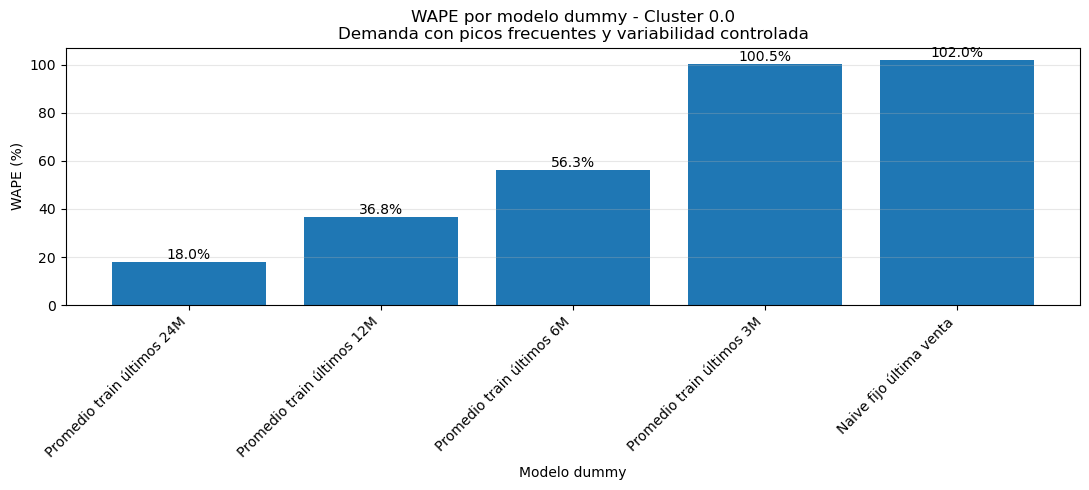

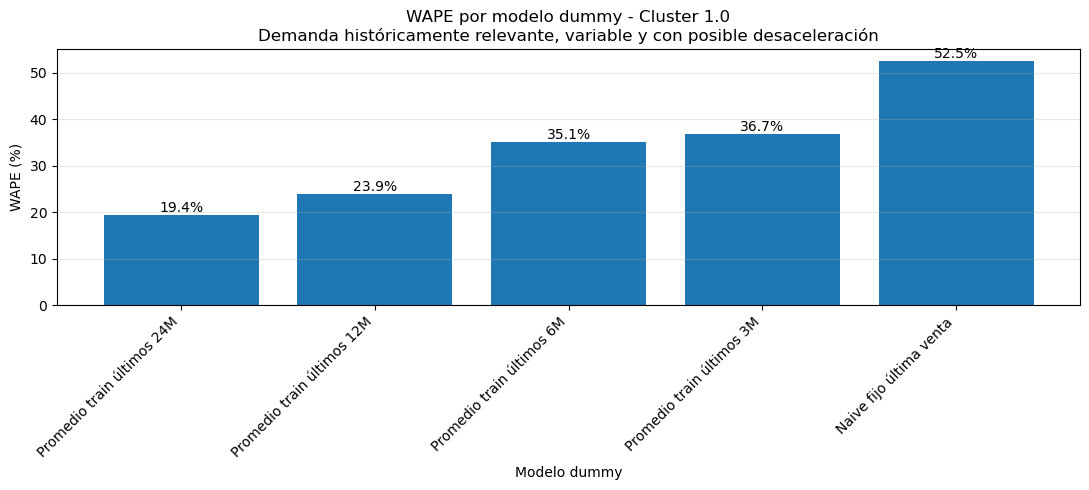

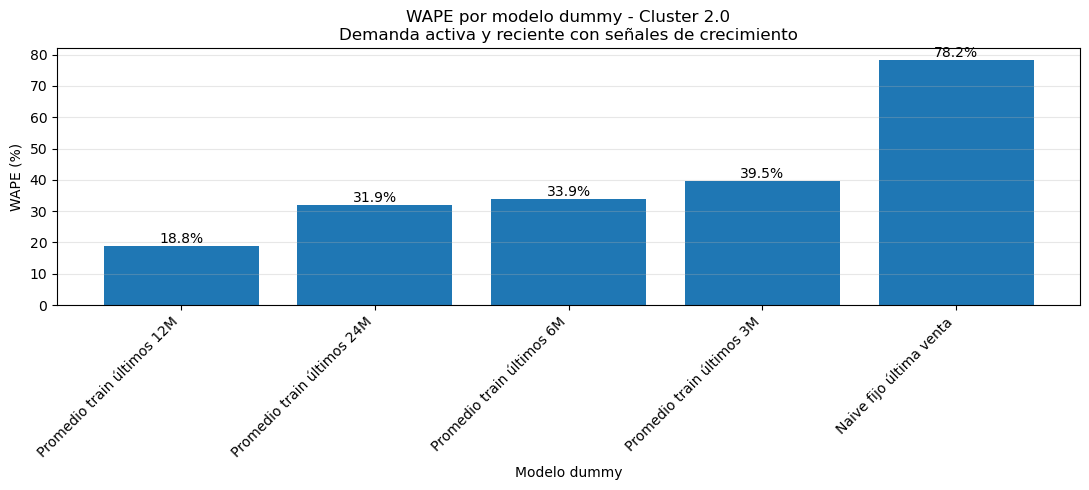

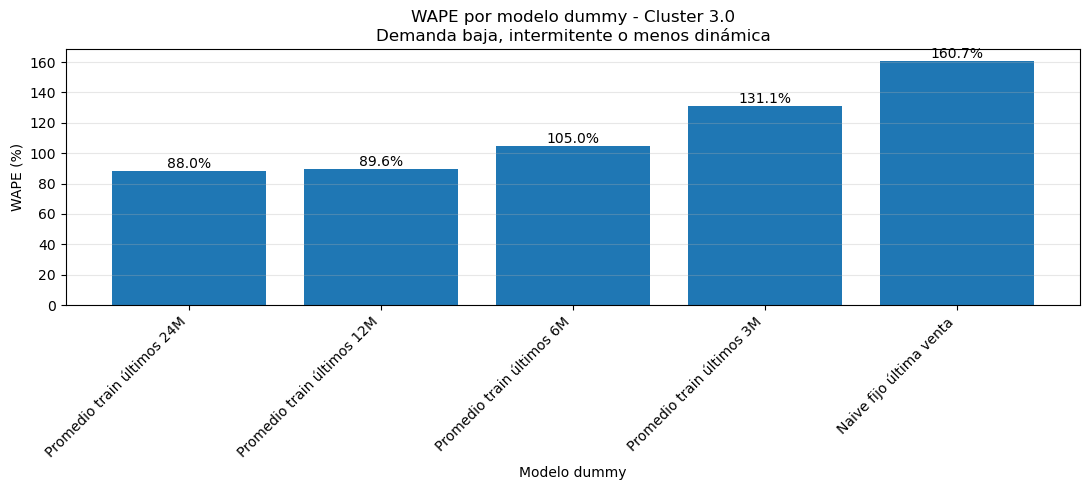

In [65]:
# ============================================================
# 30. Gráfica de WAPE por cluster y modelo dummy
# ============================================================

for cluster in sorted(df_metricas_dummy_cluster["cluster_kmeans_final"].dropna().unique()):

    df_plot_cluster = (
        df_metricas_dummy_cluster[
            df_metricas_dummy_cluster["cluster_kmeans_final"] == cluster
        ]
        .sort_values("WAPE")
        .copy()
    )

    descripcion = df_plot_cluster["descripcion_cluster"].iloc[0]

    plt.figure(figsize=(11, 5))

    plt.bar(
        df_plot_cluster["modelo_dummy"],
        df_plot_cluster["WAPE"]
    )

    plt.title(
        f"WAPE por modelo dummy - Cluster {cluster}\n"
        f"{descripcion}"
    )
    plt.xlabel("Modelo dummy")
    plt.ylabel("WAPE (%)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)

    for i, valor in enumerate(df_plot_cluster["WAPE"]):
        plt.text(
            i,
            valor,
            f"{valor:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

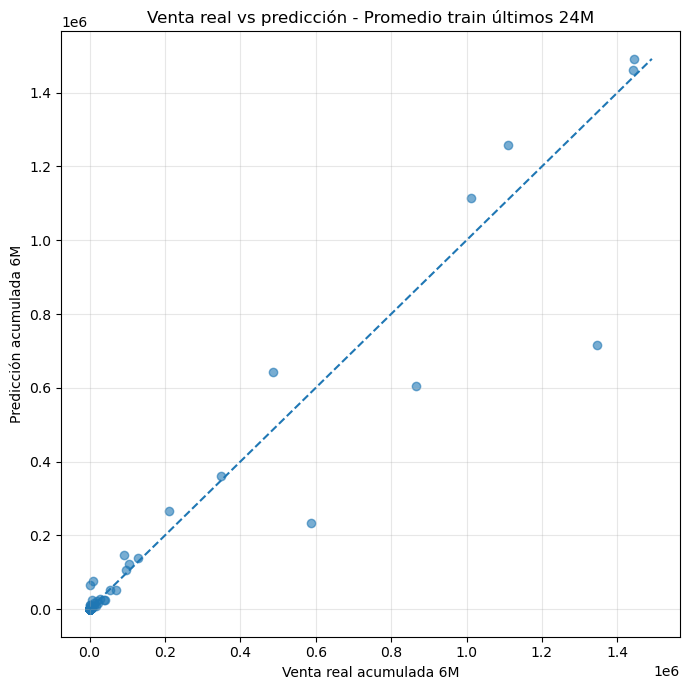

In [66]:
# ============================================================
# 31. Real vs predicción del mejor dummy global
# ============================================================

mejor_modelo_dummy_global = df_mejor_dummy_global["modelo_dummy"].iloc[0]

df_plot_real_pred_dummy = df_predicciones_dummy[
    df_predicciones_dummy["modelo_dummy"] == mejor_modelo_dummy_global
].copy()

plt.figure(figsize=(7, 7))

plt.scatter(
    df_plot_real_pred_dummy["venta_real_test"],
    df_plot_real_pred_dummy["prediccion_test"],
    alpha=0.6
)

max_valor = max(
    df_plot_real_pred_dummy["venta_real_test"].max(),
    df_plot_real_pred_dummy["prediccion_test"].max()
)

plt.plot(
    [0, max_valor],
    [0, max_valor],
    linestyle="--"
)

plt.title(f"Venta real vs predicción - {mejor_modelo_dummy_global}")
plt.xlabel(f"Venta real acumulada {meses_validacion}M")
plt.ylabel(f"Predicción acumulada {meses_validacion}M")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# 33. Convertir series temporales a matriz mensual por artículo
# ============================================================
# Objetivo:
# Crear un dataframe donde cada fila sea un artículo y cada columna
# mensual represente la venta de ese artículo en un mes específico.
# ============================================================

df_matriz_ventas = (
    df_series
    .pivot_table(
        index="codigo_articulo",
        columns="fecha_mes",
        values="venta_mensual",
        aggfunc="sum"
    )
    .sort_index(axis=1)
    .fillna(0)
)

print("Dimensiones de la matriz temporal:")
print(df_matriz_ventas.shape)

df_matriz_ventas.tail()

Dimensiones de la matriz temporal:
(450, 31)


fecha_mes,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,...,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31
codigo_articulo,,,,,,,,,,,,,,,,,,,,,
W16H6,0.00,0.00,550.00,1400.00,250.00,250.0,550.00,0.00,0.00,0.00,...,150.00,650.00,150.00,0.00,550.00,150.00,1000.00,200.0,100.00,0.0
W25H6,0.00,51.00,100.00,50.00,0.00,426.0,100.00,100.00,0.00,0.00,...,350.00,700.00,300.00,100.00,300.00,600.00,190.00,100.0,350.00,0.0
W30H6,0.00,0.00,350.00,300.00,300.00,50.0,850.00,0.00,450.00,0.00,...,0.00,100.00,600.00,700.00,700.00,1050.00,0.00,350.0,0.00,0.0
W8,760551.23,171915.98,556403.94,246344.18,172938.17,156202.2,125519.63,16735.95,1347209.33,550345.95,...,265753.43,348684.12,248249.93,87399.77,197016.75,801122.44,305712.68,0.0,136393.95,0.0
XPZ1400,10.00,4.00,2.00,0.00,0.00,0.0,0.00,6.00,0.00,11.00,...,5.00,0.00,10.00,5.00,8.00,0.00,0.00,0.0,0.00,0.0


In [78]:
# ============================================================
# Validar tipo de las columnas de df_matriz_ventas
# ============================================================

print("Tipo del índice de columnas:")
print(type(df_matriz_ventas.columns))

print("\nTipo interno de las columnas:")
print(df_matriz_ventas.columns.dtype)

print("\nPrimeras columnas:")
print(df_matriz_ventas.columns[:5])

Tipo del índice de columnas:
<class 'pandas.DatetimeIndex'>

Tipo interno de las columnas:
datetime64[us]

Primeras columnas:
DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31'],
              dtype='datetime64[us]', name='fecha_mes', freq=None)


In [79]:
# ============================================================
# 41. Preparar matriz mensual para exportar a Excel
# ============================================================
# Objetivo:
# Exportar una matriz donde cada fila sea un artículo y cada columna
# mensual sea una venta histórica.
#
# Se recomienda convertir las columnas datetime a nombres tipo:
# venta_2024_01, venta_2024_02, ...
# porque Excel y los modelos trabajan mejor con nombres de columnas tipo texto.
# ============================================================

df_matriz_export = df_matriz_ventas.copy()

# Asegurar que las columnas estén ordenadas temporalmente
df_matriz_export = df_matriz_export.sort_index(axis=1)

# Guardar mapa de columnas originales
df_mapa_fechas = pd.DataFrame({
    "columna_modelado": [
        f"venta_{fecha.year}_{fecha.month:02d}"
        for fecha in df_matriz_export.columns
    ],
    "fecha_mes": df_matriz_export.columns
})

# Renombrar columnas datetime a texto amigable
df_matriz_export.columns = [
    f"venta_{fecha.year}_{fecha.month:02d}"
    for fecha in df_matriz_export.columns
]

# Recuperar codigo_articulo como columna
df_matriz_export = df_matriz_export.reset_index()

print("Dimensiones matriz export:")
print(df_matriz_export.shape)

df_matriz_export.head()

Dimensiones matriz export:
(450, 32)


,codigo_articulo,venta_2024_01,venta_2024_02,venta_2024_03,venta_2024_04,venta_2024_05,venta_2024_06,venta_2024_07,venta_2024_08,venta_2024_09,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
1,0270H,0.0,0.0,0.0,0.0,10.0,0.0,482.0,0.0,10.0,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
2,0384-3M-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0390H-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
4,0420H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0


In [80]:
# ============================================================
# 42. Agregar trazabilidad de artículo y cluster
# ============================================================

columnas_trazabilidad = [
    "codigo_articulo",
    "descripcion_completa",
    "grupo_articulo",
    "categoria",
    "subcategoria",
    "tipo",
    "marca_fabricante",
    "unidad_medida_inventario",
    "cluster_kmeans_final",
    "descripcion_cluster"
]

columnas_trazabilidad_disponibles = [
    col for col in columnas_trazabilidad
    if col in df_series.columns
]

df_trazabilidad_articulos = (
    df_series[columnas_trazabilidad_disponibles]
    .drop_duplicates(subset=["codigo_articulo"])
    .copy()
)

df_matriz_export_cluster = df_trazabilidad_articulos.merge(
    df_matriz_export,
    on="codigo_articulo",
    how="left",
    validate="one_to_one"
)

print("Dimensiones matriz export con cluster:")
print(df_matriz_export_cluster.shape)

df_matriz_export_cluster.head()

Dimensiones matriz export con cluster:
(450, 41)


,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0


In [81]:
# ============================================================
# 43. Exportar matriz mensual a Excel
# ============================================================

ruta_excel_matriz = "./Datos/df_matriz_ventas_articulos_forecast.xlsx"

with pd.ExcelWriter(ruta_excel_matriz, engine="openpyxl") as writer:
    
    df_matriz_export_cluster.to_excel(
        writer,
        sheet_name="matriz_ventas",
        index=False
    )
    
    df_mapa_fechas.to_excel(
        writer,
        sheet_name="mapa_fechas",
        index=False
    )

print(f"Archivo exportado correctamente en: {ruta_excel_matriz}")

Archivo exportado correctamente en: ./Datos/df_matriz_ventas_articulos_forecast.xlsx
